# Predictive Modelling of Social Media Trend Emergence: A Reddit-Based Study

This project focuses on predictive modelling of social media trend emergence using Reddit data as a case study. Understanding what drives engagement and virality on social media has become increasingly important.

The objective is to analyse Reddit posts and identify key factors influencing whether a post becomes viral. Machine learning techniques are applied using textual, temporal, sentiment, and community-level features.

To guide the analysis, the following research questions are defined:

- **RQ1:** To what extent can machine learning models distinguish between viral and non-viral Reddit posts using textual, temporal, sentiment, and subreddit-level features?  
- **RQ2:** To what extent can regression models accurately predict the eventual upvote count of Reddit posts?  
- **RQ3:** How do Reddit engagement levels evolve over time, and to what extent can time-series models capture and forecast these patterns?  
- **RQ4:** How does subreddit community structure and network position influence the likelihood of Reddit posts becoming viral?

# 4.1 Data Preparation and Processing

## 4.1.1  Dataset Loading and Merging

### Import Required Libraries

In [5]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import numpy as np
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer





### Load and merge individual Subreddit Datasets

In [3]:
# Folder containing Reddit CSV files
data_folder = "reddit data"   

# Get list of all CSV files in the folder
csv_files = [f for f in os.listdir(data_folder) if f.lower().endswith(".csv")]

# Print number of files and preview first 5
print("Number of CSV files found:", len(csv_files))
print("First 5 files:", csv_files[:5])

# List to store each dataframe
df_list = []

# Loop through each CSV file
for file in csv_files:
    # Create full file path
    file_path = os.path.join(data_folder, file)
    
    # Read CSV into a dataframe
    temp_df = pd.read_csv(file_path)
    
    # If Subreddit column is missing, create it from the filename
    if "Subreddit" not in temp_df.columns:
        temp_df["Subreddit"] = file.replace("_data.csv", "").replace(".csv", "")
    
    # Add dataframe to list
    df_list.append(temp_df)

# Merge all dataframes into one dataset
df = pd.concat(df_list, ignore_index=True)

# Confirm dataset merge
print("Dataset successfully merged.")


Number of CSV files found: 31
First 5 files: ['AdviceForTeens_data.csv', 'Anxiety_reddit_data.csv', 'ApplyingToCollege_data.csv', 'astrology_data.csv', 'business_data.csv']
Dataset successfully merged.


### Inspect Dataset Structure

In [4]:
print("Columns:")
print(df.columns)
print("Dataset shape (rows, columns):", df.shape)

df.head()

Columns:
Index(['Unnamed: 0', 'ID', 'is_Original', 'Flair', 'num_comments', 'Title',
       'Subreddit', 'Body', 'URL', 'Upvotes', 'Comments', 'creation_date',
       'is_original'],
      dtype='object')
Dataset shape (rows, columns): (29179, 13)


,Unnamed: 0,ID,is_Original,Flair,num_comments,Title,Subreddit,Body,URL,Upvotes,Comments,creation_date,is_original
0,0.0,fcpbui,False,NaN,13,Can't have sex the same,AdviceForTeens,"I'm in a relationship of 2 years, naturally be...",https://www.reddit.com/r/AdviceForTeens/commen...,24,Have you tried trying your hardest to just con...,2020-03-03 12:39:21,NaN
1,1.0,fbtk1w,False,NaN,3,How to break up with a friend in the most peac...,AdviceForTeens,I’d love for us to slide off of each other but...,https://www.reddit.com/r/AdviceForTeens/commen...,18,there’s really two ways you can do this.\r\nth...,2020-03-01 20:44:48,NaN
2,2.0,1681jg,False,NaN,4,[MODPOST] [META] Lets bring this subreddit bac...,AdviceForTeens,Hey everyone! I'm one of your friendly neighbo...,https://www.reddit.com/r/AdviceForTeens/commen...,21,Me: http://i.imgur.com/QqKyW.jpg\r\n\r\nI also...,2013-01-09 10:23:30,NaN
3,3.0,fcmxds,False,NaN,0,The most important thing when texting a girl i...,AdviceForTeens,Here are some tips on how to text a girl and s...,https://www.reddit.com/r/AdviceForTeens/commen...,18,NaN,2020-03-03 09:33:01,NaN
4,4.0,f9gz1a,False,NaN,15,"My dad found my porn, help",AdviceForTeens,So.. I got a virus onto my laptop so my dad de...,https://www.reddit.com/r/AdviceForTeens/commen...,18,"How old are you? If you’re of reasonable age, ...",2020-02-26 04:51:52,NaN


In [4]:
print("\nDataset structure:")
df.info()


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29179 entries, 0 to 29178
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     26311 non-null  float64
 1   ID             29179 non-null  object 
 2   is_Original    26311 non-null  object 
 3   Flair          12636 non-null  object 
 4   num_comments   29179 non-null  int64  
 5   Title          29179 non-null  object 
 6   Subreddit      29179 non-null  object 
 7   Body           16405 non-null  object 
 8   URL            29179 non-null  object 
 9   Upvotes        29179 non-null  int64  
 10  Comments       27163 non-null  object 
 11  creation_date  29179 non-null  object 
 12  is_original    2868 non-null   object 
dtypes: float64(1), int64(2), object(10)
memory usage: 2.9+ MB


### Feature Selection and Removal of Irrelevant Variables

In [5]:
# Drop unnecessary columns
df = df.drop(columns=[
    "Unnamed: 0",   # useless index column
    "URL",          # not used
    "Comments",     # comment text (not needed)
    "Flair",        # not used in this project
    "is_Original",  # duplicate
    "is_original"   # not needed for this coursework
], errors="ignore")

# Keep only relevant columns for the project
keep_cols = [
    "ID",
    "Title",
    "Body",
    "Upvotes",
    "creation_date",
    "Subreddit",
    "num_comments"
]

df = df[keep_cols]

print("Final columns used for modelling:")
print(df.columns)
print("Dataset shape (rows, columns):", df.shape)
df.head()



Final columns used for modelling:
Index(['ID', 'Title', 'Body', 'Upvotes', 'creation_date', 'Subreddit',
       'num_comments'],
      dtype='object')
Dataset shape (rows, columns): (29179, 7)


,ID,Title,Body,Upvotes,creation_date,Subreddit,num_comments
0,fcpbui,Can't have sex the same,"I'm in a relationship of 2 years, naturally be...",24,2020-03-03 12:39:21,AdviceForTeens,13
1,fbtk1w,How to break up with a friend in the most peac...,I’d love for us to slide off of each other but...,18,2020-03-01 20:44:48,AdviceForTeens,3
2,1681jg,[MODPOST] [META] Lets bring this subreddit bac...,Hey everyone! I'm one of your friendly neighbo...,21,2013-01-09 10:23:30,AdviceForTeens,4
3,fcmxds,The most important thing when texting a girl i...,Here are some tips on how to text a girl and s...,18,2020-03-03 09:33:01,AdviceForTeens,0
4,f9gz1a,"My dad found my porn, help",So.. I got a virus onto my laptop so my dad de...,18,2020-02-26 04:51:52,AdviceForTeens,15


### Save Intermediate Merged Dataset

In [6]:
df.to_csv("reddit_merged_raw_selected.csv", index=False)
print("Saved: reddit_merged_raw_selected.csv")


Saved: reddit_merged_raw_selected.csv


## 4.1.2 Data Cleaning

### Data Type Conversion

In [7]:
# Convert numeric columns
df["Upvotes"] = pd.to_numeric(df["Upvotes"], errors="coerce")
df["num_comments"] = pd.to_numeric(df["num_comments"], errors="coerce")

# Convert timestamp
df["creation_date"] = pd.to_datetime(df["creation_date"], errors="coerce")

print("Data types after conversion:")
print(df.dtypes)


Data types after conversion:
ID                       object
Title                    object
Body                     object
Upvotes                   int64
creation_date    datetime64[ns]
Subreddit                object
num_comments              int64
dtype: object


### Missing Value Handling

In [8]:
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
ID                   0
Title                0
Body             12774
Upvotes              0
creation_date        0
Subreddit            0
num_comments         0
dtype: int64


In [9]:
# Replace missing text with empty string
df["Title"] = df["Title"].fillna("")
df["Body"] = df["Body"].fillna("")

# Drop rows missing critical modelling fields
before = df.shape[0]
df = df.dropna(subset=["Upvotes", "creation_date", "Subreddit"])
after = df.shape[0]

print("Rows removed due to missing critical fields:", before - after)
print("Shape after missing value handling:", df.shape)


Rows removed due to missing critical fields: 0
Shape after missing value handling: (29179, 7)


### Duplicate Removal (ID-based)

Duplicate posts were removed based on Reddit post IDs, which uniquely identify submissions across subreddit datasets. This prevents removal of legitimate posts that may share similar textual content.

In [10]:
# Check duplicates
duplicate_count = df.duplicated(subset=["ID"]).sum()
print("Duplicate rows detected (by ID):", duplicate_count)

# Remove duplicates
before = df.shape[0]
df = df.drop_duplicates(subset=["ID"])
after = df.shape[0]

print("Duplicate rows removed:", before - after)
print("Dataset size after deduplication:", df.shape)



Duplicate rows detected (by ID): 843
Duplicate rows removed: 843
Dataset size after deduplication: (28336, 7)


### Integrity Checks

In [11]:
print("Upvotes min/max:", df["Upvotes"].min(), df["Upvotes"].max())
print("Number of unique subreddits:", df["Subreddit"].nunique())
print(df[["Upvotes", "num_comments"]].describe())


Upvotes min/max: 0 199296
Number of unique subreddits: 30
             Upvotes  num_comments
count   28336.000000  28336.000000
mean     3954.029221    165.082157
std     13181.436901    492.276645
min         0.000000      0.000000
25%        14.000000      6.000000
50%       271.000000     41.000000
75%       898.000000    116.000000
max    199296.000000  15433.000000


### Inspect final Dataset Structure

In [12]:
print("Final columns used for modelling:")
print(df.columns)
print("Dataset shape (rows, columns):", df.shape)

display(df.head())

Final columns used for modelling:
Index(['ID', 'Title', 'Body', 'Upvotes', 'creation_date', 'Subreddit',
       'num_comments'],
      dtype='object')
Dataset shape (rows, columns): (28336, 7)


,ID,Title,Body,Upvotes,creation_date,Subreddit,num_comments
0,fcpbui,Can't have sex the same,"I'm in a relationship of 2 years, naturally be...",24,2020-03-03 12:39:21,AdviceForTeens,13
1,fbtk1w,How to break up with a friend in the most peac...,I’d love for us to slide off of each other but...,18,2020-03-01 20:44:48,AdviceForTeens,3
2,1681jg,[MODPOST] [META] Lets bring this subreddit bac...,Hey everyone! I'm one of your friendly neighbo...,21,2013-01-09 10:23:30,AdviceForTeens,4
3,fcmxds,The most important thing when texting a girl i...,Here are some tips on how to text a girl and s...,18,2020-03-03 09:33:01,AdviceForTeens,0
4,f9gz1a,"My dad found my porn, help",So.. I got a virus onto my laptop so my dad de...,18,2020-02-26 04:51:52,AdviceForTeens,15


In [13]:
print("\nDataset structure:")
df.info()


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
Index: 28336 entries, 0 to 29178
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             28336 non-null  object        
 1   Title          28336 non-null  object        
 2   Body           28336 non-null  object        
 3   Upvotes        28336 non-null  int64         
 4   creation_date  28336 non-null  datetime64[ns]
 5   Subreddit      28336 non-null  object        
 6   num_comments   28336 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 1.7+ MB


In [14]:
df.to_csv("reddit_cleaned.csv", index=False)
print("Cleaned dataset saved.")


Cleaned dataset saved.


## 4.1.3 Target Variable Definition

### Examine Upvote Distribution

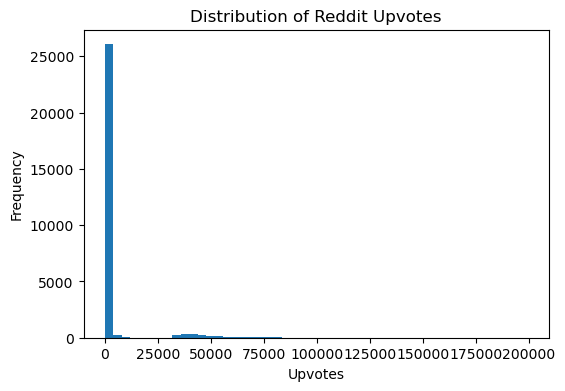

Upvote statistics:
count     28336.000000
mean       3954.029221
std       13181.436901
min           0.000000
25%          14.000000
50%         271.000000
75%         898.000000
max      199296.000000
Name: Upvotes, dtype: float64
Skewness: 4.156830321329376


In [15]:
# Plot histogram to visualise distribution of upvotes
plt.figure(figsize=(6,4))
plt.hist(df["Upvotes"], bins=50)
plt.title("Distribution of Reddit Upvotes")
plt.xlabel("Upvotes")
plt.ylabel("Frequency")
plt.show()

# Calculate descriptive statistics for upvotes
stats = df["Upvotes"].describe()

# Measure skewness to check if distribution is highly right-skewed
skewness = df["Upvotes"].skew()

print("Upvote statistics:")
print(stats)
print("Skewness:", skewness)

### Determining the Viral Threshold (Top 10%) and creating a Binary Viral Label

In [16]:
# Define viral threshold using the 90th percentile of upvotes
viral_threshold = df["Upvotes"].quantile(0.90)

# Display the calculated threshold value
print("Viral threshold (90th percentile):", viral_threshold)

# Create binary viral label based on the threshold
# 1 = viral (top 10%), 0 = non-viral
df["is_viral"] = (df["Upvotes"] >= viral_threshold).astype(int)

# Check class distribution (counts)
print("Viral label distribution:")
print(df["is_viral"].value_counts())

# Check class distribution (proportions)
print(df["is_viral"].value_counts(normalize=True))

Viral threshold (90th percentile): 2391.0
Viral label distribution:
is_viral
0    25502
1     2834
Name: count, dtype: int64
is_viral
0    0.899986
1    0.100014
Name: proportion, dtype: float64


# 4.2 Text Preprocessing

## 4.2.1 Combine Title + Body

In [17]:
# Fill missing values and ensure text format
df["Title"] = df["Title"].fillna("").astype(str)
df["Body"]  = df["Body"].fillna("").astype(str)

# Combine title and body into one text field
df["full_text"] = (
    df["Title"].str.strip() + " " + df["Body"].str.strip()
).str.strip()

# Quick check
print("full_text created:", "full_text" in df.columns)
df[["Title", "Body", "full_text"]].head()

full_text created: True


,Title,Body,full_text
0,Can't have sex the same,"I'm in a relationship of 2 years, naturally be...",Can't have sex the same I'm in a relationship ...
1,How to break up with a friend in the most peac...,I’d love for us to slide off of each other but...,How to break up with a friend in the most peac...
2,[MODPOST] [META] Lets bring this subreddit bac...,Hey everyone! I'm one of your friendly neighbo...,[MODPOST] [META] Lets bring this subreddit bac...
3,The most important thing when texting a girl i...,Here are some tips on how to text a girl and s...,The most important thing when texting a girl i...
4,"My dad found my porn, help",So.. I got a virus onto my laptop so my dad de...,"My dad found my porn, help So.. I got a virus ..."


In [18]:
df[["Subreddit", "Upvotes", "creation_date", "full_text"]].head()

,Subreddit,Upvotes,creation_date,full_text
0,AdviceForTeens,24,2020-03-03 12:39:21,Can't have sex the same I'm in a relationship ...
1,AdviceForTeens,18,2020-03-01 20:44:48,How to break up with a friend in the most peac...
2,AdviceForTeens,21,2013-01-09 10:23:30,[MODPOST] [META] Lets bring this subreddit bac...
3,AdviceForTeens,18,2020-03-03 09:33:01,The most important thing when texting a girl i...
4,AdviceForTeens,18,2020-02-26 04:51:52,"My dad found my porn, help So.. I got a virus ..."


## 4.2.2  Light Normalisation 

In [19]:
def normalise_text(text: str) -> str:
    # convert text to lowercase
    text = text.lower()
    
    # replace multiple spaces/newlines with a single space
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# create normalised text column
df["text_norm"] = df["full_text"].apply(normalise_text)

# quick check that column was created
print("text_norm created:", "text_norm" in df.columns)
df[["full_text", "text_norm"]].head()

text_norm created: True


,full_text,text_norm
0,Can't have sex the same I'm in a relationship ...,can't have sex the same i'm in a relationship ...
1,How to break up with a friend in the most peac...,how to break up with a friend in the most peac...
2,[MODPOST] [META] Lets bring this subreddit bac...,[modpost] [meta] lets bring this subreddit bac...
3,The most important thing when texting a girl i...,the most important thing when texting a girl i...
4,"My dad found my porn, help So.. I got a virus ...","my dad found my porn, help so.. i got a virus ..."


## 4.2.3 Noise Removal 

In [20]:
def remove_urls_html(text: str) -> str:
    
    # Safety check for missing values
    if pd.isna(text):
        return ""
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove standalone numbers only
    text = re.sub(r"\b\d{1,2}\b", " ", text)  # remove 1–2 digit only
    
    # Clean extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to normalised text

df["text_clean"] = df["text_norm"].apply(remove_urls_html)

print("text_clean created:", "text_clean" in df.columns)

# Evidence: show rows that originally contained noise
# (URLs, HTML, or standalone numbers)

noise_mask = df["text_norm"].str.contains(
    r'https?://|www\.|<.*?>|\b\d+\b',
    regex=True,
    na=False
)

print("Number of rows containing removable noise:", noise_mask.sum())

print("\nBefore vs After cleaning examples:")
df.loc[noise_mask, ["text_norm", "text_clean"]].head(10)

text_clean created: True
Number of rows containing removable noise: 12404

Before vs After cleaning examples:


,text_norm,text_clean
0,can't have sex the same i'm in a relationship ...,can't have sex the same i'm in a relationship ...
2,[modpost] [meta] lets bring this subreddit bac...,[modpost] [meta] lets bring this subreddit bac...
3,the most important thing when texting a girl i...,the most important thing when texting a girl i...
5,how to tell my parents i want to get medical a...,how to tell my parents i want to get medical a...
6,golden advice that can help you 1. if you wast...,golden advice that can help you . if you waste...
7,if you need advice i’ve got some for you if yo...,if you need advice i’ve got some for you if yo...
8,"everything’s changing i’m 17 and a senior, so ...","everything’s changing i’m and a senior, so you..."
9,i’m 14 and i lied about having a gf and a girl...,i’m and i lied about having a gf and a girl wi...
10,advice on crushes? it’s pretty basic to have t...,advice on crushes? it’s pretty basic to have t...
11,"i’m 13 and i still play with toys, and everyon...","i’m and i still play with toys, and everyone (..."


# 4.3 Feature engineering

## 4.3.1 Create Text-Based Features (Length + Word Count)

In [21]:
# total number of characters in cleaned text
df["text_length"] = df["text_clean"].str.len()

# total number of words in cleaned text
df["word_count"] = df["text_clean"].str.split().apply(len)

# measure title and body length separately 
df["title_length"] = df["Title"].str.len()
df["body_length"] = df["Body"].str.len()

# Quick check of created features
print("Text feature columns created:",
      ["text_length", "word_count", "title_length", "body_length"])

df[["text_length", "word_count", "title_length", "body_length"]].head()

Text feature columns created: ['text_length', 'word_count', 'title_length', 'body_length']


,text_length,word_count,title_length,body_length
0,619,116,23,601
1,841,169,64,789
2,1293,237,101,1289
3,302,65,246,84
4,425,87,26,402


In [22]:
df[["text_length","word_count","Upvotes","Subreddit"]].head()

,text_length,word_count,Upvotes,Subreddit
0,619,116,24,AdviceForTeens
1,841,169,18,AdviceForTeens
2,1293,237,21,AdviceForTeens
3,302,65,18,AdviceForTeens
4,425,87,18,AdviceForTeens


## 4.3.2 Text Vectorisation 

### Initialise TF-IDF vectoriser

Tokenisation was handled internally by the TF-IDF vectoriser, which automatically segments cleaned text into meaningful terms for feature extraction.
To avoid data leakage, the TF-IDF vectoriser was fitted only on the training data and then applied to both the training and test sets. The implementation of this transformation, including vocabulary inspection and feature matrix construction, is presented later in Section 4.5.1 (Modelling Data Preparation).

In [32]:
tfidf = TfidfVectorizer(
    max_features=5000,      # keep top 5000 important words
    stop_words='english',   # remove common English stopwords
    ngram_range=(1, 2),      # use unigrams + bigrams
)

print("TF-IDF vectoriser initialised.")

TF-IDF vectoriser initialised.


## 4.3.3 Sentiment Feature Engineering (VADER)

### Initialise VADER + Generate Sentiment Scores

In [23]:
# Download VADER lexicon 
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jolin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [24]:
# Initialise VADER
sia = SentimentIntensityAnalyzer()

# Function to extract sentiment scores
def get_sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return pd.Series([
        scores["neg"],
        scores["neu"],
        scores["pos"],
        scores["compound"]
    ])

# Apply to cleaned text
df[["sent_neg", "sent_neu", "sent_pos", "sent_compound"]] = df["text_clean"].apply(get_sentiment_scores)

# Quick check
print("Sentiment features created.")
df[["text_clean", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head()

Sentiment features created.


,text_clean,sent_neg,sent_neu,sent_pos,sent_compound
0,can't have sex the same i'm in a relationship ...,0.209,0.769,0.022,-0.9808
1,how to break up with a friend in the most peac...,0.050,0.855,0.095,0.6794
2,[modpost] [meta] lets bring this subreddit bac...,0.085,0.761,0.155,0.9322
3,the most important thing when texting a girl i...,0.104,0.816,0.080,-0.3832
4,"my dad found my porn, help so.. i got a virus ...",0.038,0.815,0.146,0.8890


### Validate Sentiment Features

Sentiment summary statistics:


,sent_neg,sent_neu,sent_pos,sent_compound
count,28336.000000,28336.000000,28336.000000,28336.000000
mean,0.084398,0.805179,0.109997,0.159368
std,0.112541,0.152157,0.118159,0.635147
min,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,0.725000,0.000000,-0.314175
50%,0.050000,0.813000,0.094000,0.000000
75%,0.125000,0.908000,0.161000,0.787600
max,1.000000,1.000000,1.000000,1.000000



Missing values in sentiment features:
sent_neg         0
sent_neu         0
sent_pos         0
sent_compound    0
dtype: int64


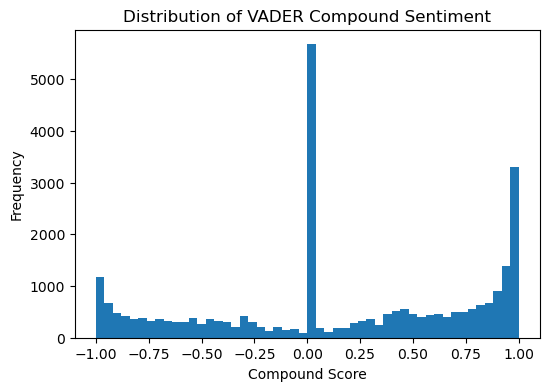

In [25]:
# Summary statistics
print("Sentiment summary statistics:")
display(df[["sent_neg", "sent_neu", "sent_pos", "sent_compound"]].describe())

# Check missing values
print("\nMissing values in sentiment features:")
print(df[["sent_neg", "sent_neu", "sent_pos", "sent_compound"]].isna().sum())

# Plot compound sentiment distribution
plt.figure(figsize=(6,4))
plt.hist(df["sent_compound"], bins=50)
plt.title("Distribution of VADER Compound Sentiment")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.show()

## 4.3.4 Temporal Features

### Confirm Datetime Format

In [26]:
print("creation_date dtype:", df["creation_date"].dtype)

# Display sample timestamps to visually verify correctness
df[["creation_date"]].head()

creation_date dtype: datetime64[ns]


,creation_date
0,2020-03-03 12:39:21
1,2020-03-01 20:44:48
2,2013-01-09 10:23:30
3,2020-03-03 09:33:01
4,2020-02-26 04:51:52


In [27]:
# These features capture posting time patterns that may which may influence Reddit engagement and virality.
# Hour of posting (0–23)
df["post_hour"] = df["creation_date"].dt.hour

# Day of week (Monday=0, Sunday=6)
df["post_dayofweek"] = df["creation_date"].dt.dayofweek

# Month of posting (1–12)
df["post_month"] = df["creation_date"].dt.month

print("Temporal features created: post_hour, post_dayofweek, post_month")

# Quick preview
df[["creation_date", "post_hour", "post_dayofweek", "post_month"]].head()

Temporal features created: post_hour, post_dayofweek, post_month


,creation_date,post_hour,post_dayofweek,post_month
0,2020-03-03 12:39:21,12,1,3
1,2020-03-01 20:44:48,20,6,3
2,2013-01-09 10:23:30,10,2,1
3,2020-03-03 09:33:01,9,1,3
4,2020-02-26 04:51:52,4,2,2


### Create Weekend Feature

In [28]:
# Weekend posts may exhibit different engagement patterns.
# Saturday = 5, Sunday = 6 (pandas weekday convention)

df["is_weekend"] = df["post_dayofweek"].isin([5, 6]).astype(int)

print("Weekend feature created.")

# Quick check
df[["post_dayofweek", "is_weekend"]].head()
print("\nWeekend distribution:")
print(df["is_weekend"].value_counts(normalize=True))

Weekend feature created.

Weekend distribution:
is_weekend
0    0.7518
1    0.2482
Name: proportion, dtype: float64


In [29]:
# These checks ensure extracted time features are valid
# and free from unexpected values.

print("post_hour range:",
      df["post_hour"].min(), "to", df["post_hour"].max())

print("Unique dayofweek values:",
      sorted(df["post_dayofweek"].unique()))

print("Unique month values:",
      sorted(df["post_month"].unique()))

print("\nWeekend distribution:")
print(df["is_weekend"].value_counts(normalize=True))

post_hour range: 0 to 23
Unique dayofweek values: [0, 1, 2, 3, 4, 5, 6]
Unique month values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Weekend distribution:
is_weekend
0    0.7518
1    0.2482
Name: proportion, dtype: float64


## 4.3.5 Community-Level Features

The primary community-level feature used in this study is subreddit_post_count, which represents the number of posts observed within each subreddit. This feature reflects the relative activity level of different communities.

To prevent data leakage, this feature was computed after the train/test split using only the training data. The resulting counts were then mapped to both the training and test sets. The implementation of this step is therefore presented later in Section 4.4.1 (Modelling Data Preparation).

## 4.3.6 Target Transformation

Text(0.5, 1.0, 'Log-Transformed Upvotes Distribution')

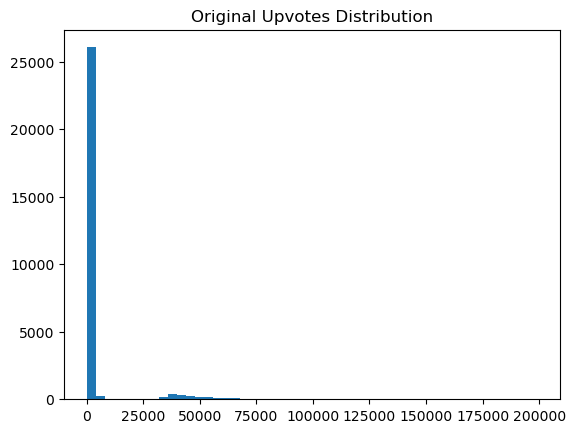

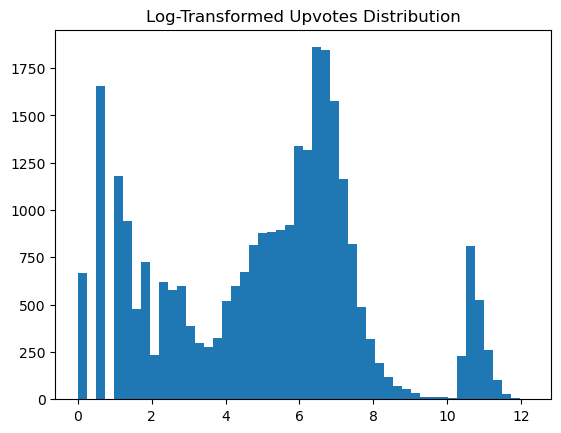

In [31]:
# Log-transform upvotes to reduce skewness for regression
df["log_upvotes"] = np.log1p(df["Upvotes"])

plt.hist(df["Upvotes"], bins=50)
plt.title("Original Upvotes Distribution")

plt.figure()
plt.hist(df["log_upvotes"], bins=50)
plt.title("Log-Transformed Upvotes Distribution")

# 4.4 Model Training and Validation

## 4.4.1 Modelling Data Preparation

### Stratified Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

# Split the dataframe 
df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["is_viral"]
)

print("Train df shape:", df_train.shape)
print("Test df shape:", df_test.shape)

print("\nTrain class distribution:")
print(df_train["is_viral"].value_counts(normalize=True))

print("\nTest class distribution:")
print(df_test["is_viral"].value_counts(normalize=True))


Train df shape: (22668, 24)
Test df shape: (5668, 24)

Train class distribution:
is_viral
0    0.899991
1    0.100009
Name: proportion, dtype: float64

Test class distribution:
is_viral
0    0.899965
1    0.100035
Name: proportion, dtype: float64


### Community-Level Feature Construction

In [34]:
# Count subreddit activity using TRAIN only
train_sub_counts = df_train["Subreddit"].value_counts()

# Add feature to train and test by mapping from TRAIN counts
df_train["subreddit_post_count"] = df_train["Subreddit"].map(train_sub_counts)
df_test["subreddit_post_count"] = df_test["Subreddit"].map(train_sub_counts)

# If any subreddit appears only in test, fill with 0
df_test["subreddit_post_count"] = df_test["subreddit_post_count"].fillna(0)

print("subreddit_post_count added safely (train-only counts).")
print("Train range:", df_train["subreddit_post_count"].min(), "to", df_train["subreddit_post_count"].max())
print("Test range:", df_test["subreddit_post_count"].min(), "to", df_test["subreddit_post_count"].max())

subreddit_post_count added safely (train-only counts).
Train range: 38 to 1989
Test range: 38 to 1989


In [35]:
df_train[["Subreddit", "subreddit_post_count"]].head()
df_test[["Subreddit", "subreddit_post_count"]].head()

,Subreddit,subreddit_post_count
11299,dating,809
9579,COVID19,823
12619,jobs,1989
20219,kidsrights,382
793,AdviceForTeens,658


### TF-IDF Transformation (Train-Only Fitting)

In [36]:
# TF-IDF: fit on TRAIN only, transform TRAIN and TEST
train_text = df_train["text_clean"].astype(str)
test_text  = df_test["text_clean"].astype(str)

X_train_tfidf = tfidf.fit_transform(train_text)
X_test_tfidf  = tfidf.transform(test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (22668, 5000)
TF-IDF test shape: (5668, 5000)


### Numeric Feature Scaling and Feature Matrix Integration

In [37]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "text_length", "word_count", "title_length", "body_length",
    "sent_neg", "sent_neu", "sent_pos", "sent_compound",
    "num_comments",
    "post_hour", "post_dayofweek", "post_month", "is_weekend",
    "subreddit_post_count"
]

# Numeric features for train/test
X_train_num = df_train[numeric_features].values
X_test_num  = df_test[numeric_features].values

# Scale numeric features (fit on TRAIN only)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

# Combine TF-IDF + scaled numeric
X_train = hstack([X_train_tfidf, X_train_num_scaled])
X_test  = hstack([X_test_tfidf, X_test_num_scaled])

# Targets
y_train = df_train["is_viral"].astype(int).values
y_test  = df_test["is_viral"].astype(int).values

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

Final X_train shape: (22668, 5014)
Final X_test shape: (5668, 5014)
y_train: (22668,) y_test: (5668,)


## 4.4.2 Classification Modelling (RQ1)

To what extent can machine-learning models distinguish viral from non-viral Reddit posts using textual, temporal, sentiment, and subreddit-level features?

### 4.4.2.1 Logistic Regression

#### Baseline Logistic Regression

Logistic Regression Results

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5101
           1       0.69      0.85      0.76       567

    accuracy                           0.95      5668
   macro avg       0.83      0.90      0.86      5668
weighted avg       0.95      0.95      0.95      5668

Confusion Matrix:
[[4882  219]
 [  87  480]]

ROC-AUC: 0.9750


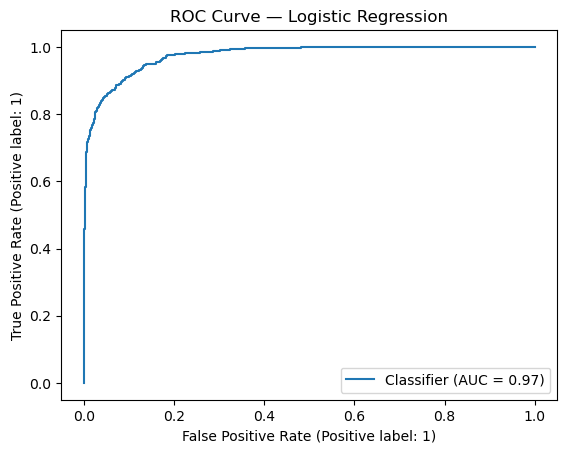

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Initialize baseline model
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train on training set
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_lr_clf = logreg.predict(X_test)
y_prob_lr_clf = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression Results\n")

# Classification report
print(classification_report(y_test, y_pred_lr_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_clf))

# ROC-AUC
roc_lr = roc_auc_score(y_test, y_prob_lr_clf)
print(f"\nROC-AUC: {roc_lr:.4f}")

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_prob_lr_clf)
plt.title("ROC Curve — Logistic Regression")
plt.show()

####  Cross-Validation (Stratified K-Fold)

In [39]:
#  Cross-Validation (Training Set Only)
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Reuse the same baseline model
logreg_cv = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate multiple metrics
cv_results = cross_validate(
    logreg_cv,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("Cross-Validation Results (Logistic Regression)\n")

# Print mean ± std
for metric in cv_results:
    if metric.startswith("test_"):
        scores = cv_results[metric]
        print(f"{metric.replace('test_', '')}: "
              f"{scores.mean():.4f} ± {scores.std():.4f}")

Cross-Validation Results (Logistic Regression)

accuracy: 0.9445 ± 0.0027
precision: 0.6841 ± 0.0146
recall: 0.8289 ± 0.0147
f1: 0.7494 ± 0.0108
roc_auc: 0.9648 ± 0.0045


### 4.4.2.2 Random Forest Classifier

####  Baseline Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize baseline model
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Train on training set
rf_base.fit(X_train, y_train)

# Predict on test set
y_pred_rf_clf_base = rf_base.predict(X_test)
y_prob_rf_clf_base = rf_base.predict_proba(X_test)[:, 1]

# Classification report
print("Random Forest Classifier Baseline Results\n")
print(classification_report(y_test, y_pred_rf_clf_base))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_clf_base))

# ROC-AUC
roc_rf_base = roc_auc_score(y_test, y_prob_rf_clf_base)
print(f"\nROC-AUC: {roc_rf_base:.4f}")

Random Forest Classifier Baseline Results

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5101
           1       0.99      0.66      0.80       567

    accuracy                           0.97      5668
   macro avg       0.98      0.83      0.89      5668
weighted avg       0.97      0.97      0.96      5668

Confusion Matrix:
[[5099    2]
 [ 190  377]]

ROC-AUC: 0.9647


####  Hyperparameter Tuning (GridSearchCV)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Parameter grid 
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}

# Grid search with stratified CV
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit on TRAINING DATA ONLY
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF CV score:", grid_rf.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best RF parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV score: 0.7960320985705949


####  Tuned Random Forest Classifier - Test Evaluation (Best Model)

Tuned Random Forest Classifier Test Results

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5101
           1       0.99      0.66      0.80       567

    accuracy                           0.97      5668
   macro avg       0.98      0.83      0.89      5668
weighted avg       0.97      0.97      0.96      5668

Confusion Matrix:
[[5099    2]
 [ 190  377]]

ROC-AUC: 0.9647


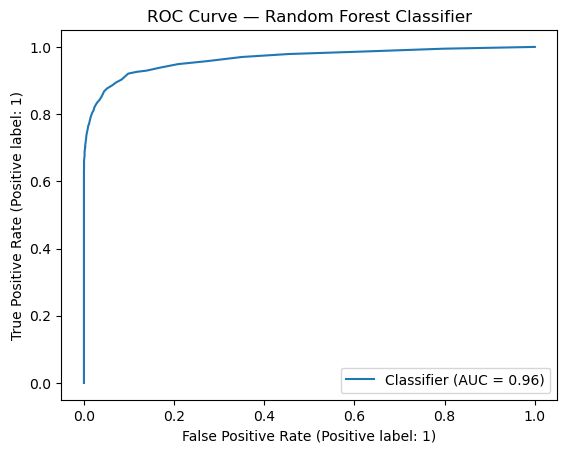

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf_clf = best_rf.predict(X_test)
y_prob_rf_clf = best_rf.predict_proba(X_test)[:, 1]

# Classification report
print("Tuned Random Forest Classifier Test Results\n")
print(classification_report(y_test, y_pred_rf_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_clf))

# Confusion matrix
roc_rf = roc_auc_score(y_test, y_prob_rf_clf)
print(f"\nROC-AUC: {roc_rf:.4f}")

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_prob_rf_clf)
plt.title("ROC Curve — Random Forest Classifier")
plt.show()

### 4.4.2.3 XGBoost Classifier (Boosted Trees) 

### Baseline XGBoost

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Try import
try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("XGBoost is not installed. Install it with: pip install xgboost")

# Handle imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", round(scale_pos_weight, 3))

# Initialize baseline model
xgb_base = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    n_jobs=-1
)

# Train on training set
xgb_base.fit(X_train, y_train)

# Predict on test set
y_pred_xgb_clf_base = xgb_base.predict(X_test)
y_prob_xgb_clf_base = xgb_base.predict_proba(X_test)[:, 1]

# Classification report
print("XGBoost CLassifier Baseline Results\n")
print(classification_report(y_test, y_pred_xgb_clf_base))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_clf_base))

# ROC-AUC
roc_xgb_base = roc_auc_score(y_test, y_prob_xgb_clf_base)
print(f"\nROC-AUC: {roc_xgb_base:.4f}")

scale_pos_weight: 8.999
XGBoost CLassifier Baseline Results

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      5101
           1       0.66      0.93      0.77       567

    accuracy                           0.95      5668
   macro avg       0.83      0.94      0.87      5668
weighted avg       0.96      0.95      0.95      5668

Confusion Matrix:
[[4835  266]
 [  41  526]]

ROC-AUC: 0.9872


#### Hyperparameter Tuning (GridSearchCV)

In [44]:
from sklearn.model_selection import GridSearchCV

# Base model
xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    n_jobs=-1
)

# Parameter grid
param_grid_xgb = {
    "n_estimators": [200, 400],      
    "max_depth": [3, 5],             
    "learning_rate": [0.1],          
    "subsample": [0.8],               
    "colsample_bytree": [0.8]         
}

# Grid search with stratified CV
grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit on TRAIN only
grid_xgb.fit(X_train, y_train)

print("\nBest XGB parameters:", grid_xgb.best_params_)
print("Best XGB CV score:", grid_xgb.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best XGB parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Best XGB CV score: 0.8396084605333101


#### Tuned XGBoost Classifier - Test Evaluation (Best Model)


Tuned XGBoost Classifier Test Results

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5101
           1       0.79      0.88      0.84       567

    accuracy                           0.97      5668
   macro avg       0.89      0.93      0.91      5668
weighted avg       0.97      0.97      0.97      5668

Confusion Matrix:
[[4972  129]
 [  68  499]]

ROC-AUC: 0.9867


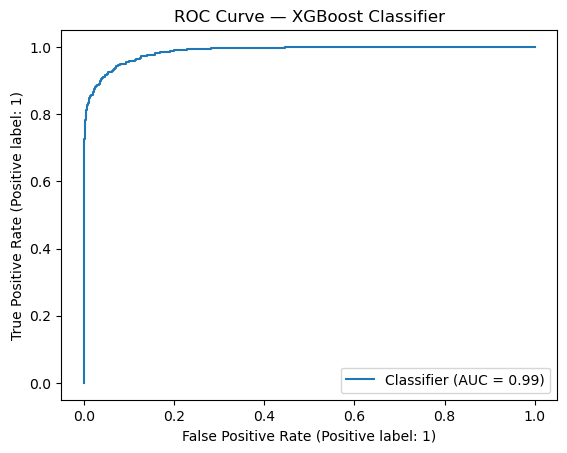

In [45]:
# Best model
best_xgb = grid_xgb.best_estimator_

# Predictions
y_pred_xgb_clf = best_xgb.predict(X_test)
y_prob_xgb_clf = best_xgb.predict_proba(X_test)[:, 1]

# Classification report
print("\nTuned XGBoost Classifier Test Results\n")
print(classification_report(y_test, y_pred_xgb_clf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_xgb_clf))

# ROC-AUC
roc_xgb = roc_auc_score(y_test, y_prob_xgb_clf)
print(f"\nROC-AUC: {roc_xgb:.4f}")

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_prob_xgb_clf)
plt.title("ROC Curve — XGBoost Classifier")
plt.show()

## 4.5.2 Regression Modelling (RQ2)

To what extent can regression models accurately predict the eventual upvote count of Reddit posts?

### 4.5.2.1 Regression Target Preparation

This step prepares the target variable for the regression task. Because Reddit upvotes are highly right-skewed, a log transformation (log1p) is applied to stabilise variance and improve model learning. The transformed target is then split into training and testing sets to ensure consistency with the classification pipeline.

In [46]:
# Target for regression (log-transformed upvotes)
# (log_upvotes created earlier in Feature Engineering)

y_reg_train = df_train["log_upvotes"].values
y_reg_test  = df_test["log_upvotes"].values

print("RQ2 regression target ready.")
print("y_reg_train shape:", y_reg_train.shape)
print("y_reg_test shape:", y_reg_test.shape)
print("Train log_upvotes range:",
      (df_train["log_upvotes"].min(), df_train["log_upvotes"].max()))
print("Test log_upvotes range:",
      (df_test["log_upvotes"].min(), df_test["log_upvotes"].max()))

RQ2 regression target ready.
y_reg_train shape: (22668,)
y_reg_test shape: (5668,)
Train log_upvotes range: (0.0, 12.202551453403197)
Test log_upvotes range: (0.0, 11.708442905191578)


### 4.5.2.2 Linear Regression

#### Baseline Linear Regression

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Targets for regression (log-transformed upvotes)
y_reg_train = df_train["log_upvotes"].values
y_reg_test  = df_test["log_upvotes"].values

# Train baseline model
linreg = LinearRegression()
linreg.fit(X_train, y_reg_train)

# Predict on test set
y_pred_lr_reg = linreg.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_reg_test, y_pred_lr_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr_reg))
r2 = r2_score(y_reg_test, y_pred_lr_reg)

print("Linear Regression Results \n")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Linear Regression Results 

MAE:  1.5388
RMSE: 1.9968
R²:   0.4808


#### Cross-Validation (K-Fold)

In [48]:
from sklearn.model_selection import KFold, cross_validate

# Define CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear regression for CV
linreg_cv = LinearRegression()

# Run cross-validation
cv_results_reg = cross_validate(
    linreg_cv,
    X_train,
    y_reg_train,
    cv=cv,
    scoring=["neg_mean_absolute_error",
             "neg_root_mean_squared_error",
             "r2"],
    n_jobs=-1
)

print("Cross-Validation Results (Linear Regression)\n")

# Convert negatives back to positive for readability
mae_scores = -cv_results_reg["test_neg_mean_absolute_error"]
rmse_scores = -cv_results_reg["test_neg_root_mean_squared_error"]
r2_scores = cv_results_reg["test_r2"]

print(f"MAE:  {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")
print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

Cross-Validation Results (Linear Regression)

MAE:  1.6207 ± 0.0143
RMSE: 2.1190 ± 0.0332
R²:   0.4086 ± 0.0302


### 4.6.2.2 Random Forest Regressor

#### Baseline Random Forest Regressor

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize baseline model
rf_reg = RandomForestRegressor(
    n_estimators=80,
    max_depth=20,       
    random_state=42,
    n_jobs=-1
)

# Train on training set
rf_reg.fit(X_train, y_reg_train)

# Predict on test set
y_pred_rf_reg_base = rf_reg.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_reg_test, y_pred_rf_reg_base)
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg_base))
r2_rf = r2_score(y_reg_test, y_pred_rf_reg_base)

print("Baseline Random Forest Regressor Results \n")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Baseline Random Forest Regressor Results 

MAE:  0.4280
RMSE: 0.6018
R²:   0.9528


#### Hyperparameter Tuning (GridSearchCV)

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Base model
rf_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Parameter grid
param_grid_rf_reg = {
"n_estimators": [50],
"max_depth": [15],
"min_samples_split": [5],
"min_samples_leaf": [2]
}

# Grid search with k-fold CV
grid_rf_reg = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid_rf_reg,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)
# Fit on TRAINING DATA ONLY
grid_rf_reg.fit(X_train, y_reg_train)

print("\nBest RF Regressor parameters:", grid_rf_reg.best_params_)
print("Best RF Regressor CV score (neg RMSE):", grid_rf_reg.best_score_)



Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best RF Regressor parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best RF Regressor CV score (neg RMSE): -0.6205596390861561


#### Tuned Random Forest Regressor - Test Evaluation (Best Model)

In [51]:
# Evaluate best model on TEST set
best_rf_reg = grid_rf_reg.best_estimator_
y_pred_best_rf = best_rf_reg.predict(X_test)

mae_best_rf = mean_absolute_error(y_reg_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_best_rf))
r2_best_rf = r2_score(y_reg_test, y_pred_best_rf)

print("\nTuned Random Forest Regressor Test Results \n")
print(f"MAE:  {mae_best_rf:.4f}")
print(f"RMSE: {rmse_best_rf:.4f}")
print(f"R²:   {r2_best_rf:.4f}")


Tuned Random Forest Regressor Test Results 

MAE:  0.4288
RMSE: 0.5988
R²:   0.9533


### 4.6.2.3 XGBoost Regressor

#### Baseline XGBoost Regressor

In [52]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize baseline model
xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Train
xgb_reg.fit(X_train, y_reg_train)

# Predict
y_pred_xgb_reg_base = xgb_reg.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_reg_test, y_pred_xgb_reg_base)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg_base))
r2 = r2_score(y_reg_test, y_pred_xgb_reg_base)

print("Baseline XGBoost Regressor Results \n")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Baseline XGBoost Regressor Results 

MAE:  0.4483
RMSE: 0.6125
R²:   0.9511


#### Hyperparameter Tuning (GridSearchCV)

In [53]:
from sklearn.model_selection import GridSearchCV

# Base model
xgb_reg_gs = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Parameter grid
param_grid_xgb_reg = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# Grid search with k-fold CV
grid_xgb_reg = GridSearchCV(
    estimator=xgb_reg_gs,
    param_grid=param_grid_xgb_reg,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Fit on TRAINING DATA ONLY
grid_xgb_reg.fit(X_train, y_reg_train)

print("\nBest XGB Regressor parameters:", grid_xgb_reg.best_params_)
print("Best XGB Regressor CV score (neg RMSE):", grid_xgb_reg.best_score_)
print("Best XGB Regressor CV RMSE:", -grid_xgb_reg.best_score_)  # convert to positive RMSE

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best XGB Regressor parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best XGB Regressor CV score (neg RMSE): -0.6300341728544969
Best XGB Regressor CV RMSE: 0.6300341728544969


#### Tuned XGBoost Regressor - Test Evaluation (Best Model)

In [54]:
# Evaluate best model on TEST set
best_xgb_reg = grid_xgb_reg.best_estimator_
y_pred_best_xgb = best_xgb_reg.predict(X_test)

mae_best = mean_absolute_error(y_reg_test, y_pred_best_xgb)
rmse_best = np.sqrt(mean_squared_error(y_reg_test, y_pred_best_xgb))
r2_best = r2_score(y_reg_test, y_pred_best_xgb)

print("\nTuned XGBoost Regressor Results \n")
print(f"MAE:  {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²:   {r2_best:.4f}")


Tuned XGBoost Regressor Results 

MAE:  0.4453
RMSE: 0.6092
R²:   0.9517


## 4.7 Time series (RQ3)

How do Reddit engagement levels evolve over time, and to what extent can time-series models capture and forecast these patterns?

### 4.5.3.1 Time Column Preparation

In [55]:
time_col = "creation_date"

# convert to datetime 
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# check for missing timestamps
print("Missing timestamps:", df[time_col].isna().sum())

# sort by time (VERY IMPORTANT for time series)
df = df.sort_values(time_col)

# set as index (recommended for ARIMA)
df_ts = df.set_index(time_col)

print("Time column prepared")
df_ts[["Upvotes","Subreddit","num_comments"]].head(10)

Missing timestamps: 0
Time column prepared


,Upvotes,Subreddit,num_comments
creation_date,,,
2008-03-17 06:00:25,710,business,268
2008-03-17 19:07:24,972,business,109
2008-03-18 17:36:39,576,business,422
2008-07-02 15:40:33,563,business,234
2008-07-29 12:18:15,746,business,125
2008-09-09 22:11:19,629,business,107
2008-09-16 23:28:12,1090,business,748
2008-09-19 10:49:34,627,business,227
2008-09-22 13:59:30,973,business,243


### 4.5.3.2 Weekly Time Series Construction

In [56]:
# aggregate weekly total upvotes
ts_weekly = df_ts["Upvotes"].resample("W").sum()

# fill missing weeks
ts_weekly = ts_weekly.fillna(0)

# quick check
print("Weekly time series length:", len(ts_weekly))
print(ts_weekly.tail(10))

Weekly time series length: 645
creation_date
2020-05-24    1371842
2020-05-31    1017026
2020-06-07     911731
2020-06-14    1053963
2020-06-21     912357
2020-06-28    1198428
2020-07-05     874221
2020-07-12    1445587
2020-07-19     819196
2020-07-26     686702
Freq: W-SUN, Name: Upvotes, dtype: int64


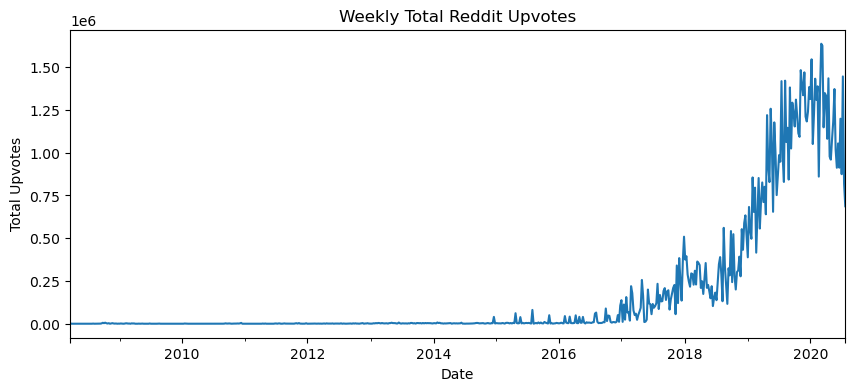

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
ts_weekly.plot()
plt.title("Weekly Total Reddit Upvotes")
plt.xlabel("Date")
plt.ylabel("Total Upvotes")
plt.show()

In [58]:
zero_weeks = (ts_weekly == 0).mean()
print(f"Zero weeks proportion: {zero_weeks:.2%}")

Zero weeks proportion: 14.88%


### 4.5.3.3 Stationarity Testing (ADF)

In [59]:
from statsmodels.tsa.stattools import adfuller

# run ADF test on WEEKLY series
adf_result = adfuller(ts_weekly)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# interpretation helper
if adf_result[1] < 0.05:
    print("Series is stationary (good for ARIMA)")
else:
    print("Series is NOT stationary (need differencing)")

ADF Statistic: -1.6665544519624544
p-value: 0.44842174560882087
Series is NOT stationary (need differencing)


### 4.5.3.4 First-Order Differencing

Differenced series length: 644


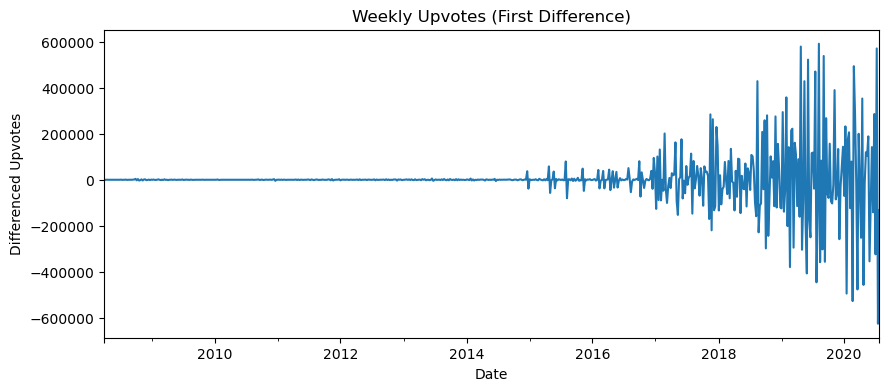

In [60]:
# apply first difference
ts_weekly_diff = ts_weekly.diff().dropna()

print("Differenced series length:", len(ts_weekly_diff))

# plot differenced series
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
ts_weekly_diff.plot(title="Weekly Upvotes (First Difference)")
plt.xlabel("Date")
plt.ylabel("Differenced Upvotes")
plt.show()

### 4.5.3.5 Stationarity Confirmation

In [61]:
from statsmodels.tsa.stattools import adfuller

adf_result_diff = adfuller(ts_weekly_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

if adf_result_diff[1] < 0.05:
    print("Differenced series is stationary")
else:
    print("Still not stationary — may need second differencing")

ADF Statistic: -3.045784180989611
p-value: 0.0308343524892797
Differenced series is stationary


### 4.5.3.6 ACF/PACF Analysis

<Figure size 1000x400 with 0 Axes>

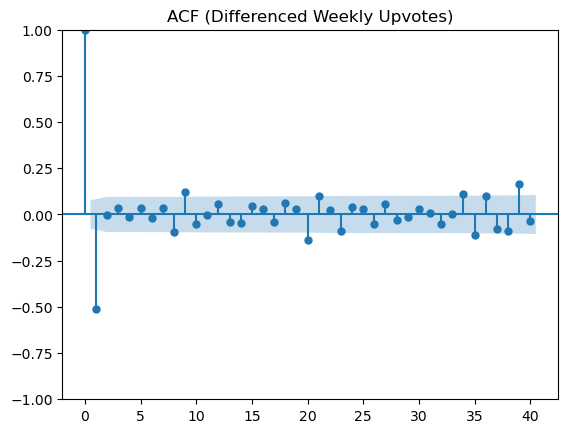

<Figure size 1000x400 with 0 Axes>

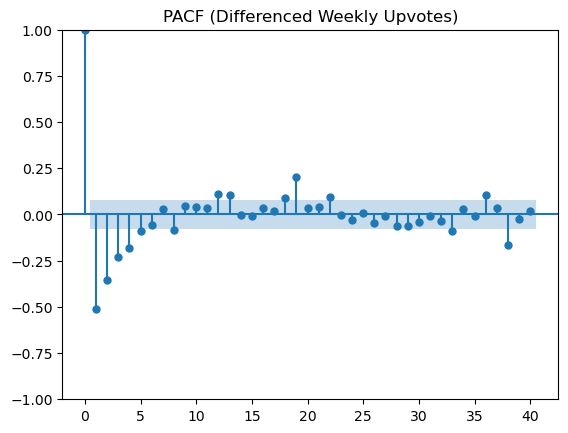

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(ts_weekly_diff, lags=40)
plt.title("ACF (Differenced Weekly Upvotes)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts_weekly_diff, lags=40, method="ywm")
plt.title("PACF (Differenced Weekly Upvotes)")
plt.show()

### 4.5.3.7 ARIMA Order Selection

In [63]:
from statsmodels.tsa.arima.model import ARIMA

# store results
arima_results = {}

# candidate orders (based on ACF/PACF)
orders = [(1,1,1), (2,1,1), (1,1,2)]

for order in orders:
    print(f"Fitting ARIMA{order}...")
    
    model = ARIMA(ts_weekly, order=order)
    fitted = model.fit()
    
    arima_results[order] = fitted.aic
    print(f"AIC for ARIMA{order}: {fitted.aic:.2f}\n")

best_order = min(arima_results, key=arima_results.get)
print("Best ARIMA order (lowest AIC):", best_order, "AIC:", arima_results[best_order])

Fitting ARIMA(1, 1, 1)...
AIC for ARIMA(1, 1, 1): 16469.12

Fitting ARIMA(2, 1, 1)...
AIC for ARIMA(2, 1, 1): 16460.17

Fitting ARIMA(1, 1, 2)...
AIC for ARIMA(1, 1, 2): 16420.45

Best ARIMA order (lowest AIC): (1, 1, 2) AIC: 16420.450585196624


In [64]:
# Fit Final ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# use best order from AIC search
final_fit = ARIMA(ts_weekly, order=(1,1,2)).fit()

print("Final ARIMA model fitted.")

Final ARIMA model fitted.


### 4.5.3.8 Final ARIMA Model

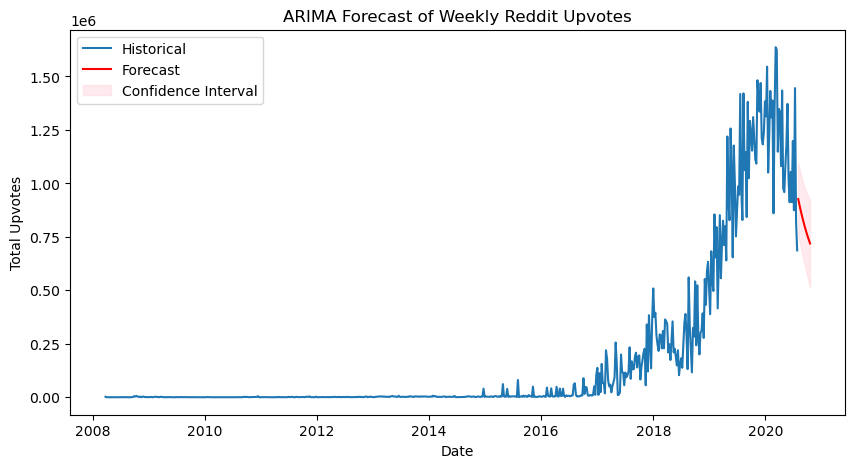

In [65]:
# Generate 12-step ahead forecast from the fitted ARIMA model
forecast_res = final_fit.get_forecast(steps=12)

# Extract predicted mean values (the forecast line)
forecast_mean = forecast_res.predicted_mean

# Extract confidence interval bounds
conf_int = forecast_res.conf_int()

# Create plot
plt.figure(figsize=(10,5))

# Plot historical weekly upvotes
plt.plot(ts_weekly, label="Historical")

# Plot forecasted values
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")

# Plot shaded confidence interval area
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],  # lower bound
    conf_int.iloc[:, 1],  # upper bound
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

# Add titles and labels
plt.title("ARIMA Forecast of Weekly Reddit Upvotes")
plt.xlabel("Date")
plt.ylabel("Total Upvotes")

# Show legend and display plot
plt.legend()
plt.show()

## 4.5.3 Subreddit Community Network Analysis (RQ4)

How does subreddit community structure and network position influence the likelihood of Reddit posts becoming viral?

### 4.5.3.1 Subreddit Document Construction

In [66]:
# select the cleaned text column used for analysis
text_col = "text_clean"

# ensure there are no missing text values
df[text_col] = df[text_col].fillna("").astype(str)

# combine all posts from each subreddit into one text document
sub_docs = df.groupby("Subreddit")[text_col].apply(lambda x: " ".join(x)).reset_index()

# rename columns 
sub_docs.columns = ["Subreddit", "sub_text"]

# check number of subreddit documents created
print("Number of subreddits:", sub_docs.shape[0])
print(sub_docs.head())

Number of subreddits: 30
           Subreddit                                           sub_text
0     AdviceForTeens  make your flair your name or what you want to ...
1            Anxiety  i think we can all relate. (found on ifunny -_...
2  ApplyingToCollege  [humor] we should start referring to uchicago ...
3            COVID19  "let's start with what we do not know" excelle...
4           Colombia  look who made to the top ten in the world beau...


### 4.5.3.2 TF-IDF Representation of Subreddits

In [67]:
# initialise TF-IDF vectoriser
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=2
)

# convert subreddit text documents into TF-IDF feature matrix
sub_tfidf = vectorizer.fit_transform(sub_docs["sub_text"])

# check resulting matrix size
print("TF-IDF matrix shape:", sub_tfidf.shape)

TF-IDF matrix shape: (30, 5000)


### 4.5.3.3 Subreddit Similarity Matrix

In [68]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# calculate cosine similarity between subreddit TF-IDF vectors
similarity_matrix = cosine_similarity(sub_tfidf)

# convert similarity matrix to dataframe 
sim_df = pd.DataFrame(
    similarity_matrix,
    index=sub_docs["Subreddit"],
    columns=sub_docs["Subreddit"]
)

print(sim_df.round(3))

Subreddit           AdviceForTeens  Anxiety  ApplyingToCollege  COVID19  \
Subreddit                                                                 
AdviceForTeens               1.000    0.725              0.668    0.071   
Anxiety                      0.725    1.000              0.555    0.076   
ApplyingToCollege            0.668    0.555              1.000    0.090   
COVID19                      0.071    0.076              0.090    1.000   
Colombia                     0.072    0.068              0.064    0.018   
Entrepreneur                 0.564    0.529              0.534    0.105   
Feminism                     0.375    0.316              0.307    0.083   
GradSchool                   0.608    0.522              0.610    0.104   
NeutralPolitics              0.278    0.275              0.307    0.135   
SuicideWatch                 0.844    0.753              0.634    0.080   
YouthRights                  0.520    0.408              0.516    0.100   
YouthandGovernment       

### 4.5.3.4 Construction of Subreddit Network Graph

In [69]:
import networkx as nx

# set similarity threshold to decide when two subreddits are connected
threshold = 0.25

# create an empty graph
G = nx.Graph()

# add subreddit nodes to the graph
for sub in sim_df.index:
    G.add_node(sub)

# add edges between subreddits if similarity is above the threshold
for i, sub1 in enumerate(sim_df.index):
    for j, sub2 in enumerate(sim_df.columns):
        if j <= i:
            continue  # skip duplicate pairs and self-connections
        weight = sim_df.loc[sub1, sub2] # similarity score

         # create edge if similarity is strong enough
        if weight >= threshold:
            G.add_edge(sub1, sub2, weight=float(weight))

# display graph summary in a more organised way
print("\n--- Subreddit Network Summary ---")
print(f"Total nodes (subreddits): {G.number_of_nodes()}") # number of subreddits
print(f"Total edges (connections): {G.number_of_edges()}") #number of connections

print("\nExample edges with similarity weights:")
for edge in list(G.edges(data=True))[:10]:
    sub1, sub2, data = edge
    print(f"{sub1}  <-->  {sub2}   | similarity = {data['weight']:.3f}")



--- Subreddit Network Summary ---
Total nodes (subreddits): 30
Total edges (connections): 292

Example edges with similarity weights:
AdviceForTeens  <-->  Anxiety   | similarity = 0.725
AdviceForTeens  <-->  ApplyingToCollege   | similarity = 0.668
AdviceForTeens  <-->  Entrepreneur   | similarity = 0.564
AdviceForTeens  <-->  Feminism   | similarity = 0.375
AdviceForTeens  <-->  GradSchool   | similarity = 0.608
AdviceForTeens  <-->  NeutralPolitics   | similarity = 0.278
AdviceForTeens  <-->  SuicideWatch   | similarity = 0.844
AdviceForTeens  <-->  YouthRights   | similarity = 0.520
AdviceForTeens  <-->  YouthandGovernment   | similarity = 0.375
AdviceForTeens  <-->  astrology   | similarity = 0.355


### 4.5.3.5 Network Centrality Calculation

In [70]:
# calculate degree centrality for each subreddit
degree_centrality = nx.degree_centrality(G)

# calculate betweenness centrality (how important a node is as a bridge)
betweenness_centrality = nx.betweenness_centrality(G)

# calculate weighted degree (strength of connections)
strength = dict(G.degree(weight="weight"))

# combine all centrality measures into one dataframe
centrality_df = pd.DataFrame({
    "Subreddit": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "betweenness_centrality": list(betweenness_centrality.values()),
    "weighted_strength": [strength[node] for node in degree_centrality.keys()]
})

# sort subreddits by strongest connections
centrality_df = centrality_df.sort_values("weighted_strength", ascending=False)

print("Most central subreddits in the similarity network:")
print(centrality_df.head(10))

Most central subreddits in the similarity network:
            Subreddit  degree_centrality  betweenness_centrality  \
28  whatsbotheringyou           0.862069                0.008740   
18    depression_help           0.793103                0.001656   
15            college           0.862069                0.008740   
0      AdviceForTeens           0.793103                0.001656   
14     careerguidance           0.862069                0.008740   
24     povertyfinance           0.862069                0.008740   
9        SuicideWatch           0.793103                0.001656   
27          teenagers           0.827586                0.005171   
17             dating           0.793103                0.001656   
20         highschool           0.827586                0.011754   

    weighted_strength  
28          15.314065  
18          14.086231  
15          14.008536  
0           13.957849  
14          13.833335  
24          13.640381  
9           13.608072  
27      

### 4.5.3.6 Visualisation of Subreddit Community Network

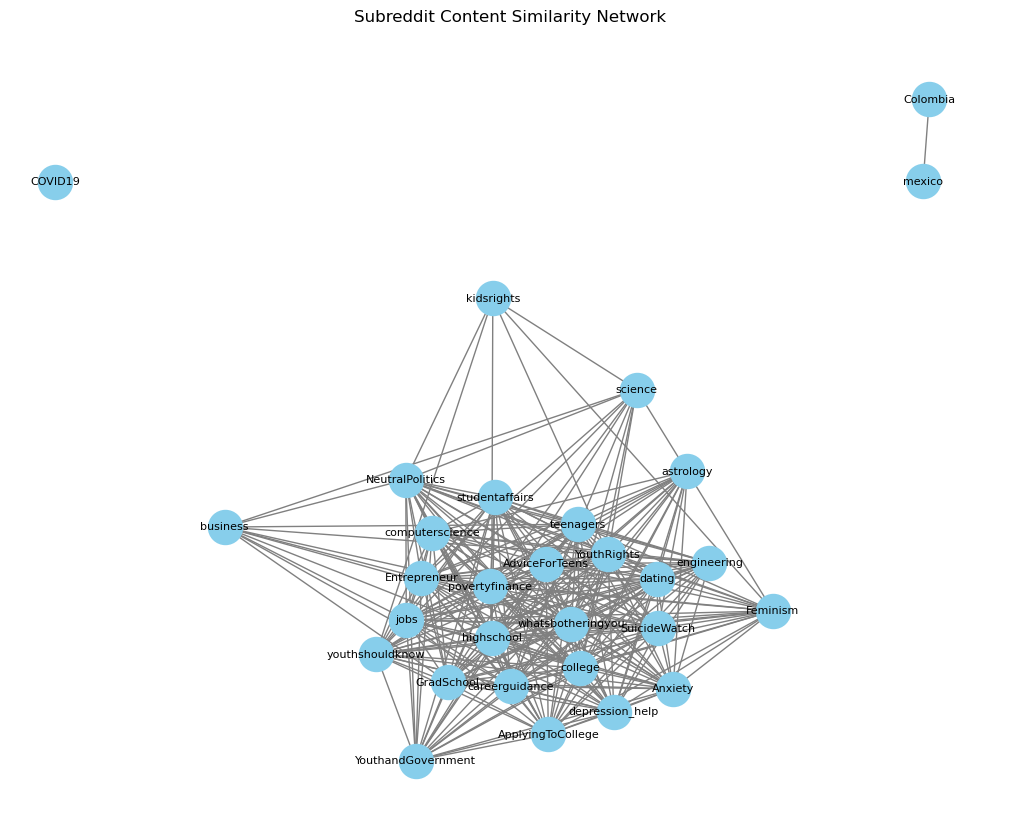

In [71]:
import matplotlib.pyplot as plt

# create figure for the network graph
plt.figure(figsize=(10,8))

# generate node positions using spring layout
# this spreads nodes based on connection strength
pos = nx.spring_layout(G, seed=42, k=0.8)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=600,
    node_color="skyblue",
    font_size=8,
    edge_color="gray"
)

plt.title("Subreddit Content Similarity Network")
plt.show()

### 4.5.3.7 Integration with Virality Statistics

In [112]:
# calculate subreddit-level statistics
# viral_rate = proportion of viral posts in each subreddit
# post_count = number of posts per subreddit
sub_stats = df.groupby("Subreddit").agg({
    "is_viral": "mean",
    "Subreddit": "count"
}).rename(columns={"Subreddit": "post_count"})

# merge network centrality metrics with subreddit statistics
# this combines network position with virality information
network_stats = centrality_df.merge(
    sub_stats.reset_index(),
    on="Subreddit",
    how="left"
)

# rename column
network_stats = network_stats.rename(columns={"is_viral": "viral_rate"})

# reorder columns so it matches the evaluation table format
cols = [
    "Subreddit",
    "viral_rate",
    "post_count",
    "degree_centrality",
    "betweenness_centrality",
    "weighted_strength"
]

# display clean formatted table
from IPython.display import display

print("Merged rows:", network_stats.shape[0])
display(network_stats[cols].head(10))

Merged rows: 30


,Subreddit,viral_rate,post_count,degree_centrality,betweenness_centrality,weighted_strength
0,whatsbotheringyou,0.000000,996,0.862069,0.008740,15.314065
1,depression_help,0.000000,1000,0.793103,0.001656,14.086231
2,college,0.041037,926,0.862069,0.008740,14.008536
3,AdviceForTeens,0.000000,818,0.793103,0.001656,13.957849
4,careerguidance,0.000000,1000,0.862069,0.008740,13.833335
5,povertyfinance,0.467677,990,0.862069,0.008740,13.640381
6,SuicideWatch,0.003043,986,0.793103,0.001656,13.608072
7,teenagers,1.000000,957,0.827586,0.005171,13.549383
8,dating,0.008056,993,0.793103,0.001656,13.238071
9,highschool,0.000000,998,0.827586,0.011754,12.976273


### 4.5.3.8 Data Validation and Merge Sanity Check

In [73]:
# --- Compare subreddit sets ---
left_subs = set(centrality_df["Subreddit"])
right_subs = set(sub_stats.reset_index()["Subreddit"])

missing_in_sub_stats = left_subs - right_subs
missing_in_centrality = right_subs - left_subs

print("Subreddits in centrality_df:", len(left_subs))
print("Subreddits in sub_stats:", len(right_subs))
print("Missing in sub_stats (present in network, absent in stats):", missing_in_sub_stats)
print("Missing in centrality_df (present in stats, absent in network):", missing_in_centrality)


# --- Row count check (left merge should not change rows) ---
print("\ncentrality_df rows:", centrality_df.shape[0])
print("network_stats rows:", network_stats.shape[0])

assert network_stats.shape[0] == centrality_df.shape[0], "Row count changed after merge!"


# --- Duplicate key check ---
dup_left = centrality_df["Subreddit"].duplicated().sum()
dup_right = sub_stats.reset_index()["Subreddit"].duplicated().sum()

print("\nDuplicate Subreddit in centrality_df:", dup_left)
print("Duplicate Subreddit in sub_stats:", dup_right)

assert dup_left == 0, "centrality_df has duplicate Subreddit keys!"
assert dup_right == 0, "sub_stats has duplicate Subreddit keys!"


# --- Check for missing viral_rate values ---
nan_count = network_stats["viral_rate"].isna().sum()
print("\nNaN viral_rate rows:", nan_count)

if nan_count > 0:
    print(network_stats[network_stats["viral_rate"].isna()][["Subreddit"]].head(10))

Subreddits in centrality_df: 30
Subreddits in sub_stats: 30
Missing in sub_stats (present in network, absent in stats): set()
Missing in centrality_df (present in stats, absent in network): set()

centrality_df rows: 30
network_stats rows: 30

Duplicate Subreddit in centrality_df: 0
Duplicate Subreddit in sub_stats: 0

NaN viral_rate rows: 0


# 4.6 Evaluation 

## 4.6.1 Classification performance (RQ1)

### 4.6.1.1 Model comparison Table

In [74]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = []

# Logistic Regression — Baseline 
results.append(
    evaluate_model(
        "Logistic Regression (Baseline)",
        y_test,
        y_pred_lr_clf,
        y_prob_lr_clf
    )
)

# Logistic Regression — CV
results.append({
    "Model": "Logistic Regression (CV)",
    "Accuracy": cv_results["test_accuracy"].mean(),
    "Precision": cv_results["test_precision"].mean(),
    "Recall": cv_results["test_recall"].mean(),
    "F1": cv_results["test_f1"].mean(),
    "ROC-AUC": cv_results["test_roc_auc"].mean()
})

# Random Forest — Baseline
results.append(
    evaluate_model(
        "Random Forest (Baseline)",
        y_test,
        y_pred_rf_clf_base,
        y_prob_rf_clf_base
    )
)

#  Random Forest — Tuned
results.append(
    evaluate_model(
        "Random Forest (GridSearch)",
        y_test,
        y_pred_rf_clf,
        y_prob_rf_clf
    )
)

# XGBoost — Baseline
results.append(
    evaluate_model(
        "XGBoost (Baseline)",
        y_test,
        y_pred_xgb_clf_base,
        y_prob_xgb_clf_base
    )
)

# XGBoost — Tuned
results.append(
    evaluate_model(
        "XGBoost (GridSearch)",
        y_test,
        y_pred_xgb_clf,
        y_prob_xgb_clf
    )
)

# Create table

comparison_df = pd.DataFrame(results).round(4)

print("Model Comparison Table (Classification)")
display(comparison_df)

Model Comparison Table (Classification)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (Baseline),0.9460,0.6867,0.8466,0.7583,0.9750
1,Logistic Regression (CV),0.9445,0.6841,0.8289,0.7494,0.9648
2,Random Forest (Baseline),0.9661,0.9947,0.6649,0.7970,0.9647
3,Random Forest (GridSearch),0.9661,0.9947,0.6649,0.7970,0.9647
4,XGBoost (Baseline),0.9458,0.6641,0.9277,0.7741,0.9872
5,XGBoost (GridSearch),0.9652,0.7946,0.8801,0.8351,0.9867


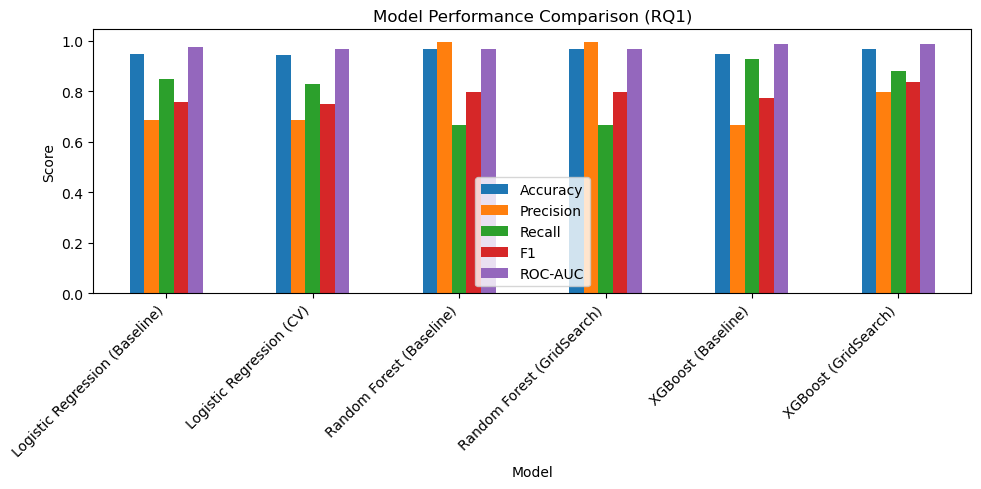

In [75]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison (RQ1)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.6.1.2 ROC Curve Comparison 

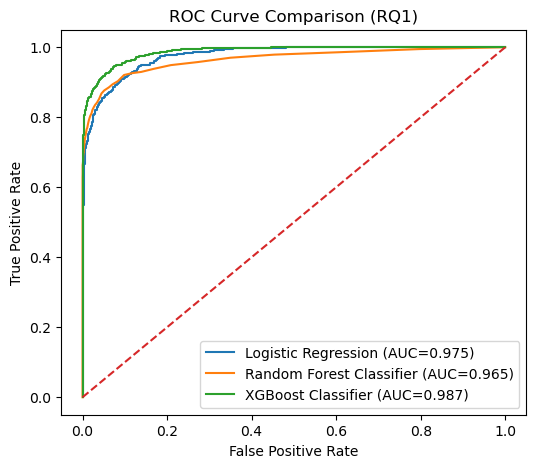

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,5))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_clf)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_lr:.3f})")

# Random Forest Classifier
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_clf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest Classifier (AUC={roc_rf:.3f})")

# XGBoost Classifier
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_clf)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost Classifier (AUC={roc_xgb:.3f})")

# Diagonal baseline
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (RQ1)")
plt.legend()
plt.show()

### 4.6.1.3 Precision–Recall Curve

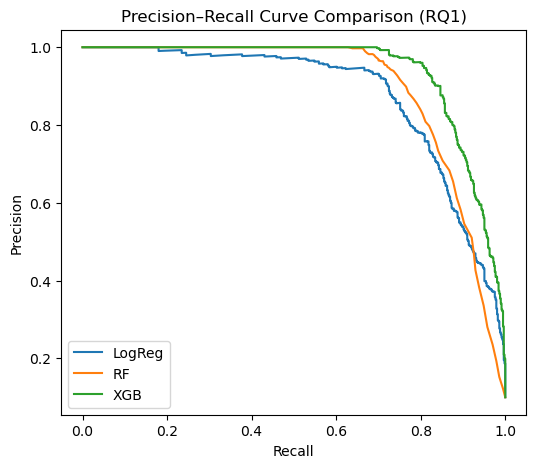

In [77]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr_clf)
plt.plot(rec_lr, prec_lr, label="LogReg")

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf_clf)
plt.plot(rec_rf, prec_rf, label="RF")

# XGBoost
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb_clf)
plt.plot(rec_xgb, prec_xgb, label="XGB")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (RQ1)")
plt.legend()
plt.show()

### 4.6.1.4 Confusion matrix grid

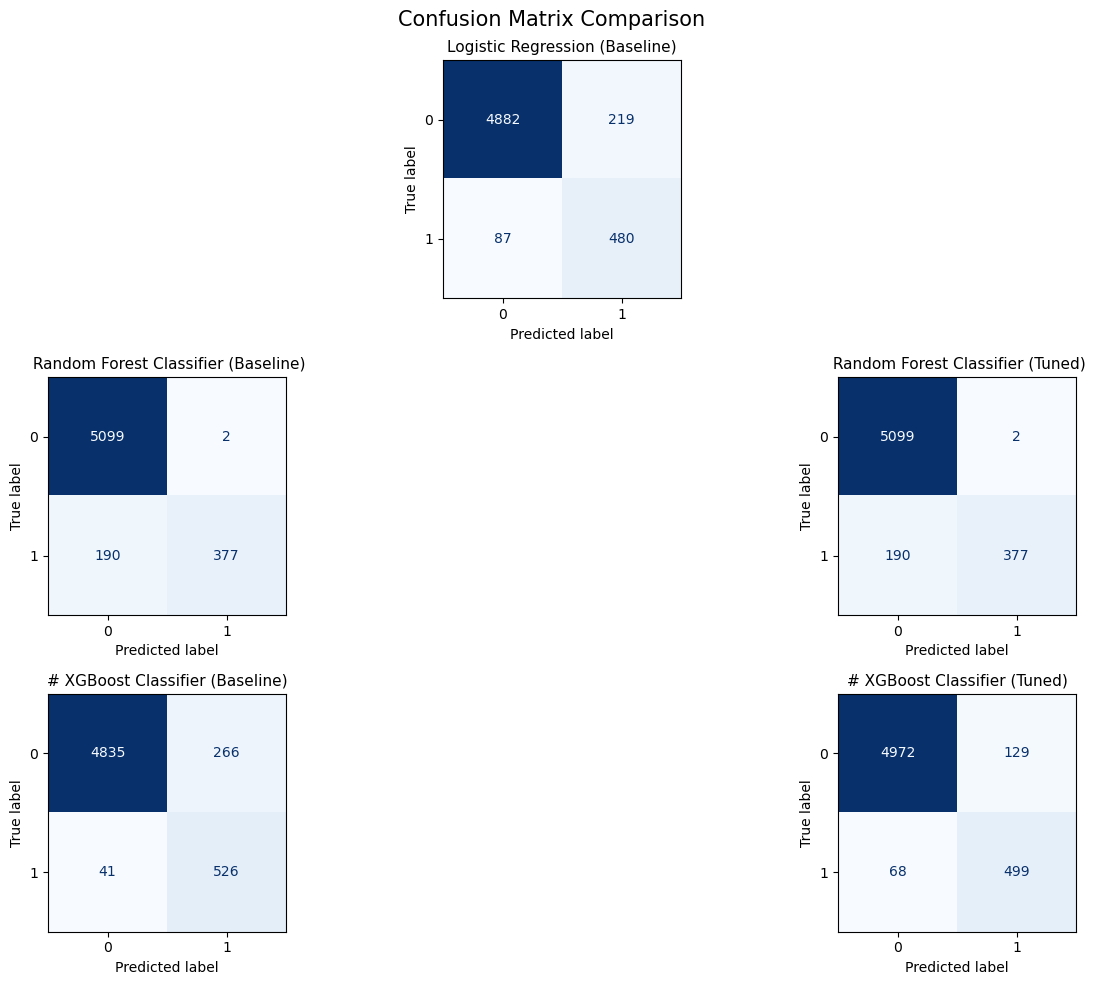

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 10))

# 3 columns gives true center control
gs = gridspec.GridSpec(3, 3)

# Logistic Regression
axA = fig.add_subplot(gs[0, 1])

#  Random Forest Classifier 
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[1, 2])

# XGBoost Classifier 
axD = fig.add_subplot(gs[2, 0])
axE = fig.add_subplot(gs[2, 2])

plots = [
    ("Logistic Regression (Baseline)", y_pred_lr_clf, axA),
    (" Random Forest Classifier (Baseline)", y_pred_rf_clf_base, axB),
    (" Random Forest Classifier (Tuned)", y_pred_rf_clf, axC),
    (" XGBoost Classifier (Baseline)", y_pred_xgb_clf_base, axD),
    (" XGBoost Classifier (Tuned)", y_pred_xgb_clf, axE),
]

for title, preds, ax in plots:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        cmap="Blues",
        ax=ax,
        values_format="d",
        colorbar=False 
    )
    ax.set_title(title, fontsize=11)

plt.suptitle("Confusion Matrix Comparison ", fontsize=15)
plt.tight_layout()
plt.show()

### 4.6.1.5 Cross-validation stability plot

In [79]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1","ROC-AUC"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
}).round(4)

cv_summary

,Metric,Mean,Std
0,Accuracy,0.9445,0.0027
1,Precision,0.6841,0.0146
2,Recall,0.8289,0.0147
3,F1,0.7494,0.0108
4,ROC-AUC,0.9648,0.0045


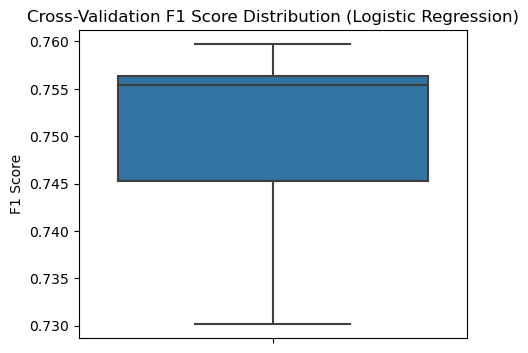

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

cv_f1_scores = cv_results["test_f1"]

plt.figure(figsize=(5,4))
sns.boxplot(y=cv_f1_scores)
plt.title("Cross-Validation F1 Score Distribution (Logistic Regression)")
plt.ylabel("F1 Score")
plt.show()

## 4.6.2 Regression performance (RQ2)

### 4.6.2.1 Model comparison

In [83]:
def evaluate_regression(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# Regression Model Comparison Table

results_reg = []

# Linear Regression — baseline
results_reg.append(
    evaluate_regression(
        "Linear Regression (Baseline)",
        y_reg_test,
        y_pred_lr_reg
    )
)

# Linear Regression — CV (use CV means)
results_reg.append({
    "Model": "Linear Regression (CV)",
    "MAE": mae_scores.mean(),
    "RMSE": rmse_scores.mean(),
    "R2": r2_scores.mean()
})

# Random Forest — baseline
results_reg.append(
    evaluate_regression(
        "RF Regressor (Baseline)",
        y_reg_test,
        y_pred_rf_reg_base
    )
)

# Random Forest — tuned
results_reg.append(
    evaluate_regression(
        "RF Regressor (GridSearch)",
        y_reg_test,
        y_pred_best_rf
    )
)

# XGBoost — baseline
results_reg.append(
    evaluate_regression(
        "XGB Regressor (Baseline)",
        y_reg_test,
        y_pred_xgb_reg_base
    )
)

# XGBoost — tuned
results_reg.append(
    evaluate_regression(
        "XGB Regressor (GridSearch)",
        y_reg_test,
        y_pred_best_xgb
    )
)

# Create dataframe
comparison_reg_df = pd.DataFrame(results_reg).round(4)

print("Regression Model Comparison\n")
display(comparison_reg_df)

Regression Model Comparison



,Model,MAE,RMSE,R2
0,Linear Regression (Baseline),1.5388,1.9968,0.4808
1,Linear Regression (CV),1.6207,2.1190,0.4086
2,RF Regressor (Baseline),0.4280,0.6018,0.9528
3,RF Regressor (GridSearch),0.4288,0.5988,0.9533
4,XGB Regressor (Baseline),0.4483,0.6125,0.9511
5,XGB Regressor (GridSearch),0.4453,0.6092,0.9517


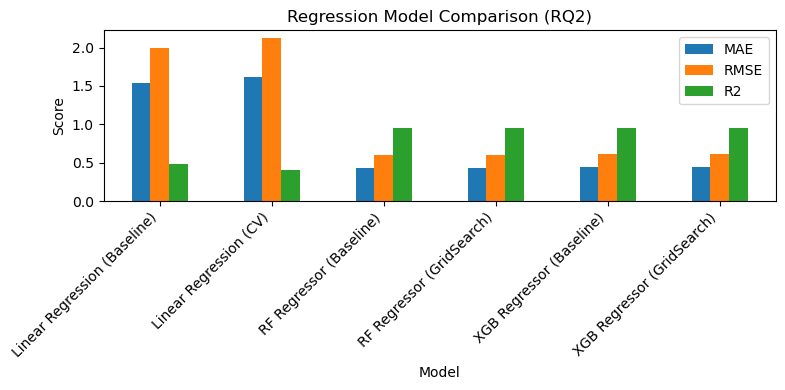

In [84]:
metrics_reg = ["MAE", "RMSE", "R2"]

comparison_reg_df.set_index("Model")[metrics_reg].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Regression Model Comparison (RQ2)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.6.2.2 Cross-Validation RMSE Across Folds (Linear Regression)

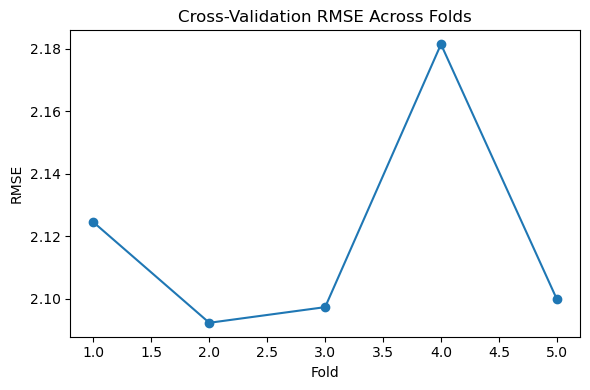

In [85]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), rmse_scores, marker="o")

plt.title("Cross-Validation RMSE Across Folds")
plt.xlabel("Fold")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

### 4.6.2.3 Actual vs Predicted Scatter Plot

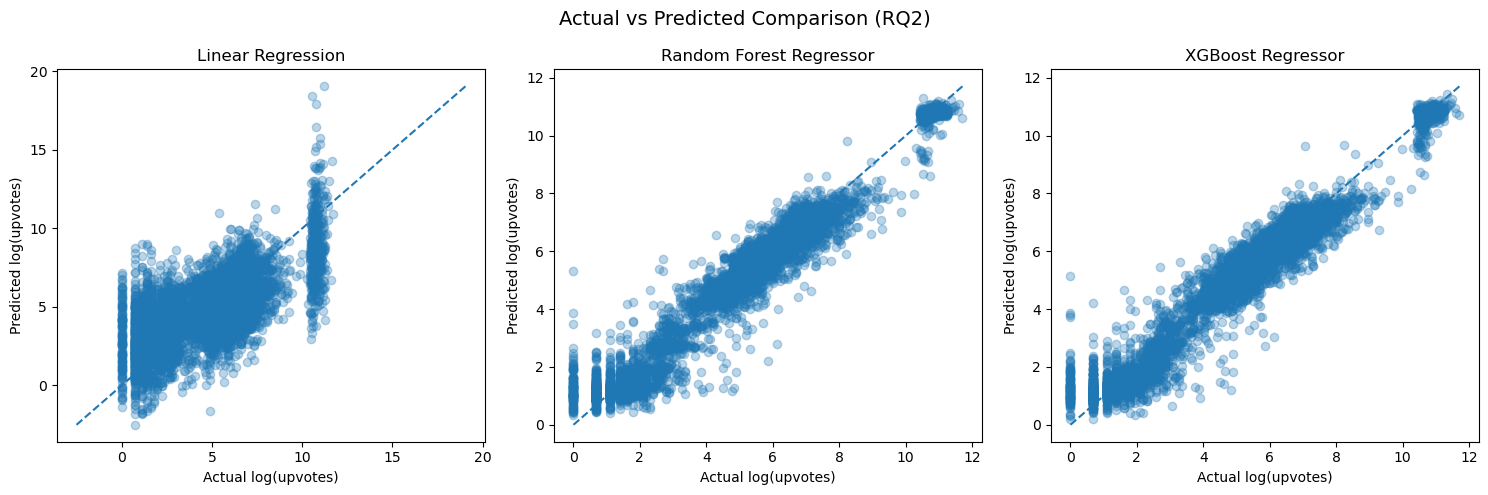

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

models = [
    ("Linear Regression", y_pred_lr_reg),
    ("Random Forest Regressor", y_pred_best_rf),
    ("XGBoost Regressor", y_pred_best_xgb)
]

for ax, (name, preds) in zip(axes, models):

    ax.scatter(y_reg_test, preds, alpha=0.3)

    min_val = min(y_reg_test.min(), preds.min())
    max_val = max(y_reg_test.max(), preds.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_title(name)
    ax.set_xlabel("Actual log(upvotes)")
    ax.set_ylabel("Predicted log(upvotes)")

plt.suptitle("Actual vs Predicted Comparison (RQ2)", fontsize=14)
plt.tight_layout()
plt.show()

### 4.6.2.4 Residual Plot Comparison

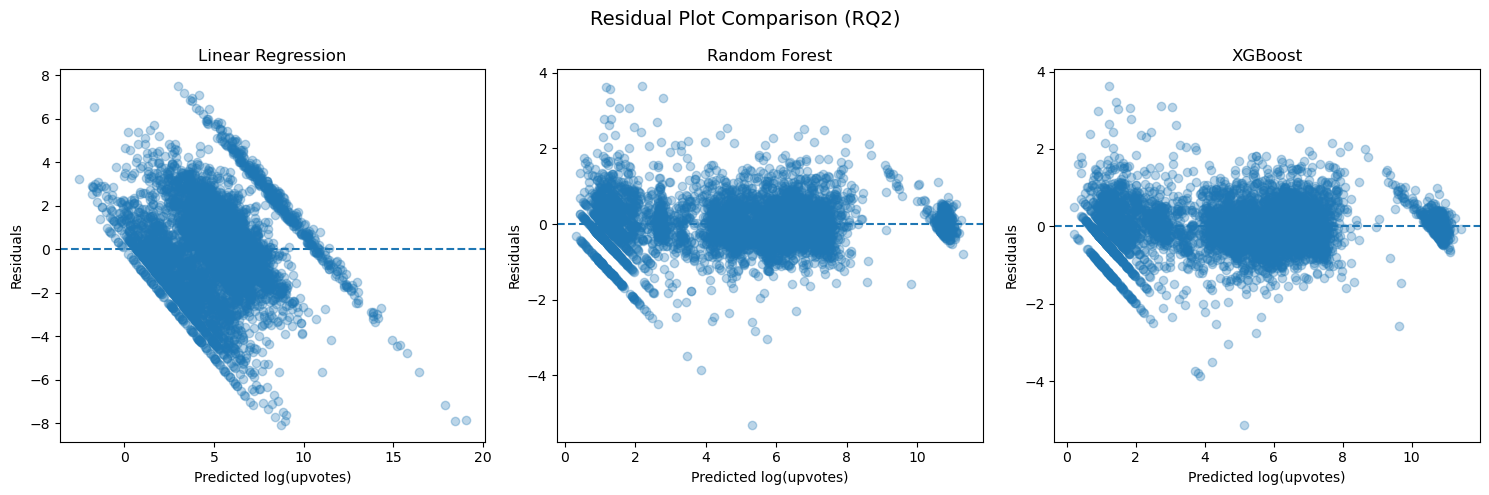

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

models = [
    ("Linear Regression", y_pred_lr_reg),
    ("Random Forest", y_pred_best_rf),
    ("XGBoost", y_pred_best_xgb)
]

for ax, (name, preds) in zip(axes, models):

    residuals = y_reg_test - preds

    ax.scatter(preds, residuals, alpha=0.3)

    ax.axhline(0, linestyle="--")

    ax.set_title(name)
    ax.set_xlabel("Predicted log(upvotes)")
    ax.set_ylabel("Residuals")

plt.suptitle("Residual Plot Comparison (RQ2)", fontsize=14)
plt.tight_layout()
plt.show()

### 4.6.2.5 Residual Distribution Comparison

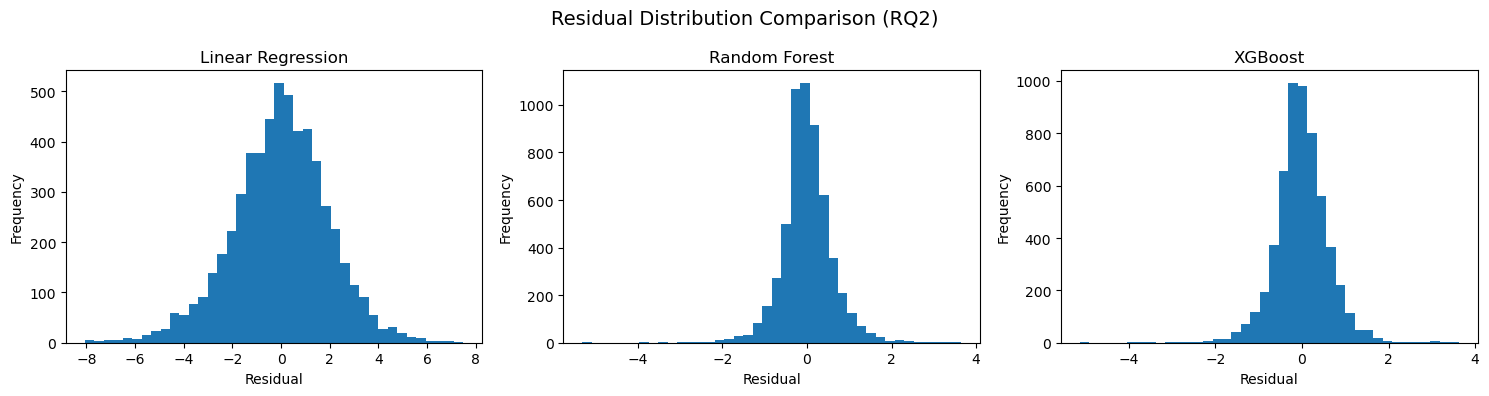

In [88]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

models = [
    ("Linear Regression", y_pred_lr_reg),
    ("Random Forest", y_pred_best_rf),
    ("XGBoost", y_pred_best_xgb)
]

for ax, (name, preds) in zip(axes, models):

    residuals = y_reg_test - preds

    ax.hist(residuals, bins=40)

    ax.set_title(name)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")

plt.suptitle("Residual Distribution Comparison (RQ2)", fontsize=14)
plt.tight_layout()
plt.show()

### 4.6.2.6 Prediction error vs actual

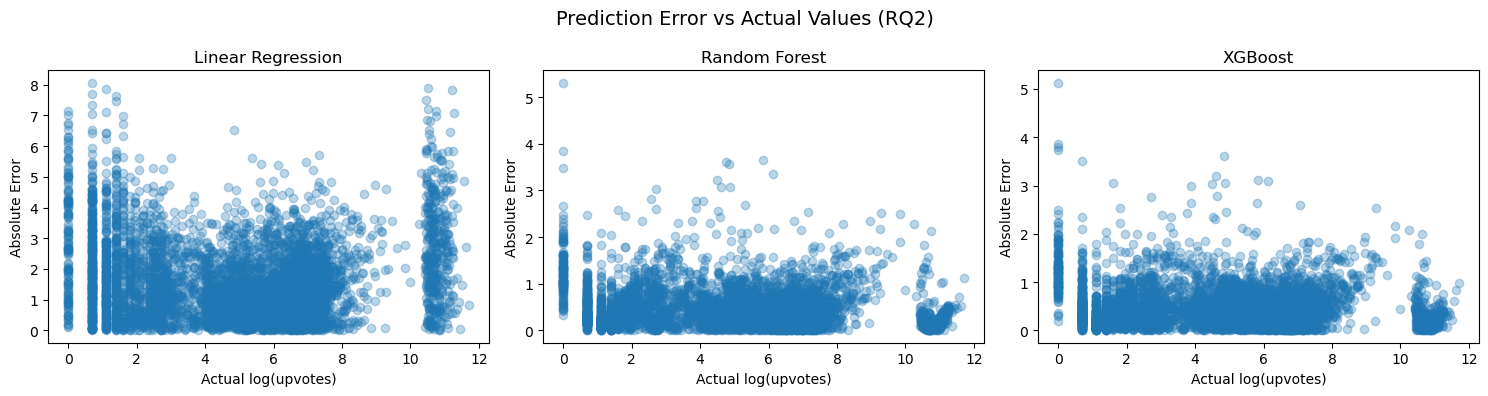

In [89]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

models = [
    ("Linear Regression", y_pred_lr_reg),
    ("Random Forest", y_pred_best_rf),
    ("XGBoost", y_pred_best_xgb)
]

for ax, (name, preds) in zip(axes, models):

    errors = abs(y_reg_test - preds)

    ax.scatter(y_reg_test, errors, alpha=0.3)

    ax.set_title(name)
    ax.set_xlabel("Actual log(upvotes)")
    ax.set_ylabel("Absolute Error")

plt.suptitle("Prediction Error vs Actual Values (RQ2)", fontsize=14)
plt.tight_layout()
plt.show()

## 4.6.3 Time-Series Analysis of Reddit Engagement 

### 4.6.3.1 Forecast Accuracy Evaluation

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# holdout last 12 weeks
train = ts_weekly.iloc[:-12]
test  = ts_weekly.iloc[-12:]

model = ARIMA(train, order=(1,1,2)).fit()
pred = model.forecast(steps=12)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("RQ3 Forecast Evaluation")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

RQ3 Forecast Evaluation
MAE: 209914.65
RMSE: 233922.18


### 4.6.3.2 Forecast vs Actual Comparison

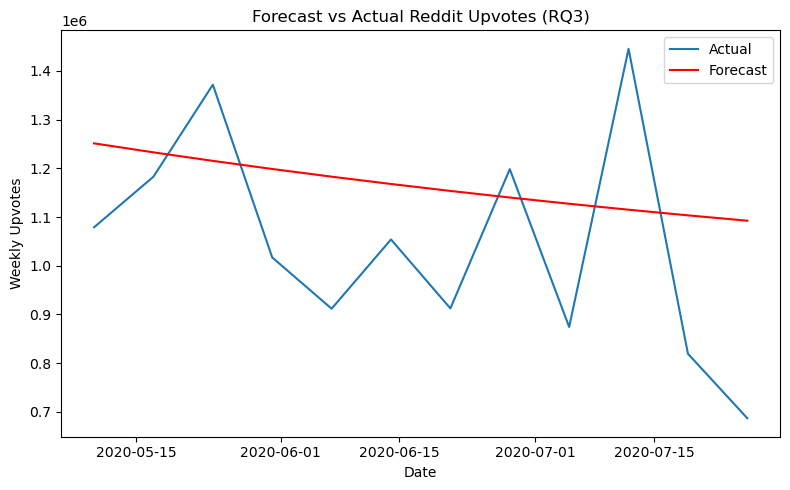

In [92]:
plt.figure(figsize=(8,5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, pred, label="Forecast", color="red")

plt.title("Forecast vs Actual Reddit Upvotes (RQ3)")
plt.xlabel("Date")
plt.ylabel("Weekly Upvotes")
plt.legend()

plt.tight_layout()
plt.show()

### 4.6.3.3 Forecast Error Over Time

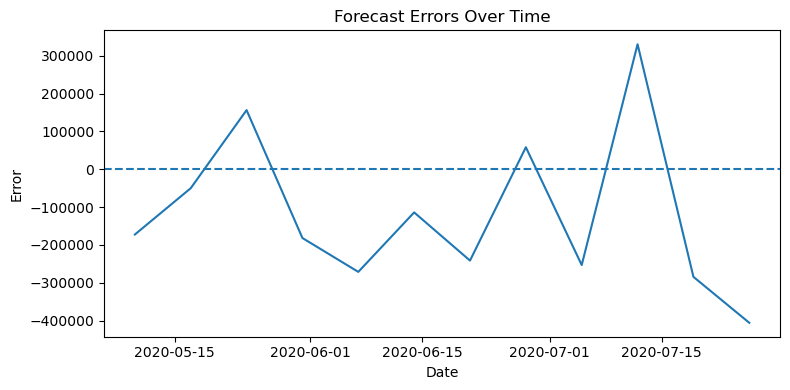

In [93]:
forecast_errors = test - pred

plt.figure(figsize=(8,4))

plt.plot(forecast_errors)

plt.axhline(0, linestyle="--")

plt.title("Forecast Errors Over Time")
plt.xlabel("Date")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

### 4.6.3.4 Forecast Error Distribution

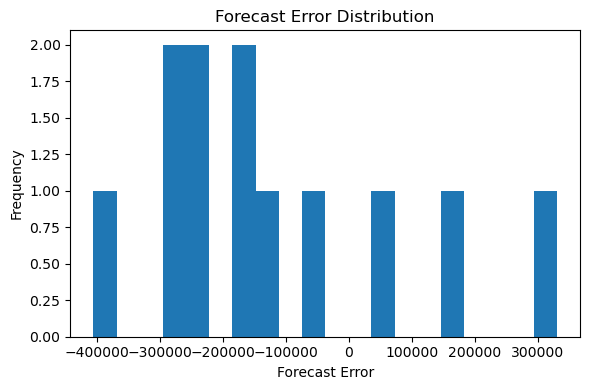

In [94]:
plt.figure(figsize=(6,4))

plt.hist(forecast_errors, bins=20)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4.6.3.5 ACF and PACF of Forecast Errors

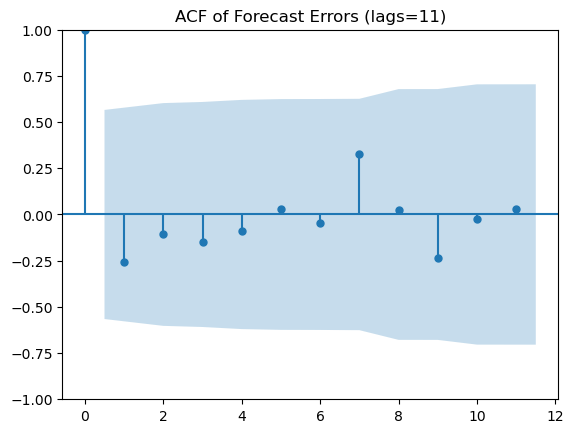

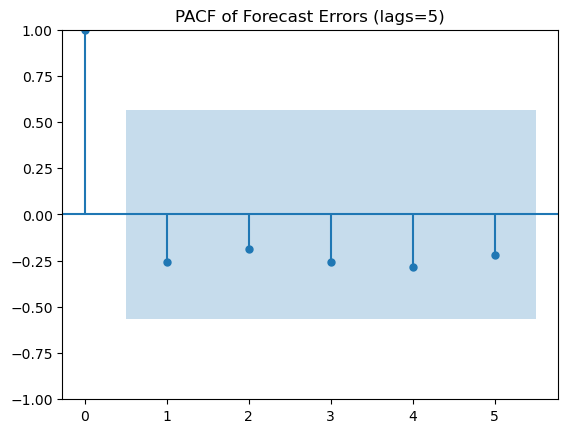

In [95]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

forecast_errors = (test - pred).dropna()
n = len(forecast_errors)

max_lags_acf  = min(20, n-1)
max_lags_pacf = min(5, (n//2)-1)

plot_acf(forecast_errors, lags=max_lags_acf)
plt.title(f"ACF of Forecast Errors (lags={max_lags_acf})")
plt.show()

plot_pacf(forecast_errors, lags=max_lags_pacf, method="ywm")
plt.title(f"PACF of Forecast Errors (lags={max_lags_pacf})")
plt.show()

## 4.6.4 Network Analysis (RQ4)

### 4.6.4.1 Subreddit Similarity Network Structure

The subreddit similarity network was visualised using the NetworkX library. A spring layout algorithm was applied to position nodes based on connection strength, allowing related communities to appear closer together. Nodes represent subreddits, while edges indicate textual similarity relationships between communities. The resulting network graph is shown in Figure 4.5.3.6 .

### 4.6.4.2 Network Centrality and Viral Engagement

#### Degree Centrality vs Viral Rate

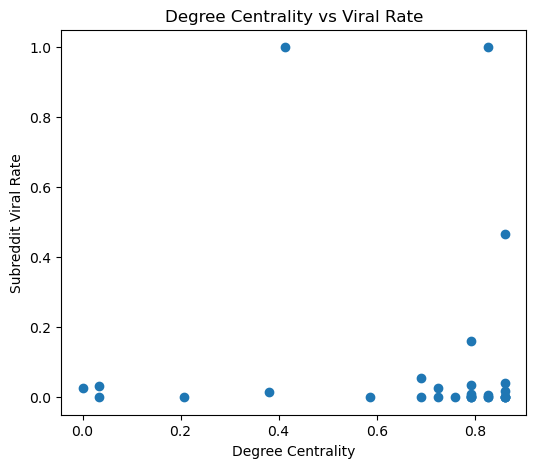

Pearson (linear): r=-0.007, p=0.9695
Spearman (rank): rho=-0.065, p=0.7310


In [113]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(eval_df["degree_centrality"], eval_df["viral_rate"])
plt.xlabel("Degree Centrality")
plt.ylabel("Subreddit Viral Rate")
plt.title("Degree Centrality vs Viral Rate")
plt.show()

# Pearson + Spearman
pear_r, pear_p = pearsonr(eval_df["degree_centrality"], eval_df["viral_rate"])
spear_rho, spear_p = spearmanr(eval_df["degree_centrality"], eval_df["viral_rate"])

print(f"Pearson (linear): r={pear_r:.3f}, p={pear_p:.4f}")
print(f"Spearman (rank): rho={spear_rho:.3f}, p={spear_p:.4f}")

#### Betweenness Centrality vs Viral Rate

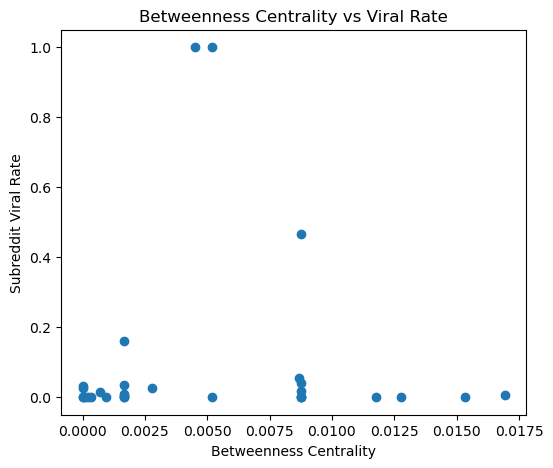

Pearson (linear): r=0.027, p=0.8855
Spearman (rank): rho=0.042, p=0.8241


In [114]:
# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(eval_df["betweenness_centrality"], eval_df["viral_rate"])
plt.xlabel("Betweenness Centrality")
plt.ylabel("Subreddit Viral Rate")
plt.title("Betweenness Centrality vs Viral Rate")
plt.show()

# Pearson + Spearman
pear_r, pear_p = pearsonr(eval_df["betweenness_centrality"], eval_df["viral_rate"])
spear_rho, spear_p = spearmanr(eval_df["betweenness_centrality"], eval_df["viral_rate"])

print(f"Pearson (linear): r={pear_r:.3f}, p={pear_p:.4f}")
print(f"Spearman (rank): rho={spear_rho:.3f}, p={spear_p:.4f}")

### 4.6.4.3  Correlation Analysis of Network Metrics

####  Correlation table

In [115]:
metric_cols = ["viral_rate", "degree_centrality", "betweenness_centrality"]
if "weighted_strength" in eval_df.columns:
    metric_cols.append("weighted_strength")

# Pearson correlation matrix
pearson_corr = eval_df[metric_cols].corr(method="pearson")
print("Pearson Correlation Matrix:")
display(pearson_corr)

# Spearman correlation matrix
spearman_corr = eval_df[metric_cols].corr(method="spearman")
print("Spearman Correlation Matrix:")
display(spearman_corr)

Pearson Correlation Matrix:


,viral_rate,degree_centrality,betweenness_centrality,weighted_strength
viral_rate,1.000000,-0.007295,0.027462,-0.001980
degree_centrality,-0.007295,1.000000,0.528203,0.911955
betweenness_centrality,0.027462,0.528203,1.000000,0.378754
weighted_strength,-0.001980,0.911955,0.378754,1.000000


Spearman Correlation Matrix:


,viral_rate,degree_centrality,betweenness_centrality,weighted_strength
viral_rate,1.000000,-0.065480,0.042356,-0.090613
degree_centrality,-0.065480,1.000000,0.822187,0.806261
betweenness_centrality,0.042356,0.822187,1.000000,0.515512
weighted_strength,-0.090613,0.806261,0.515512,1.000000


#### Heatmap

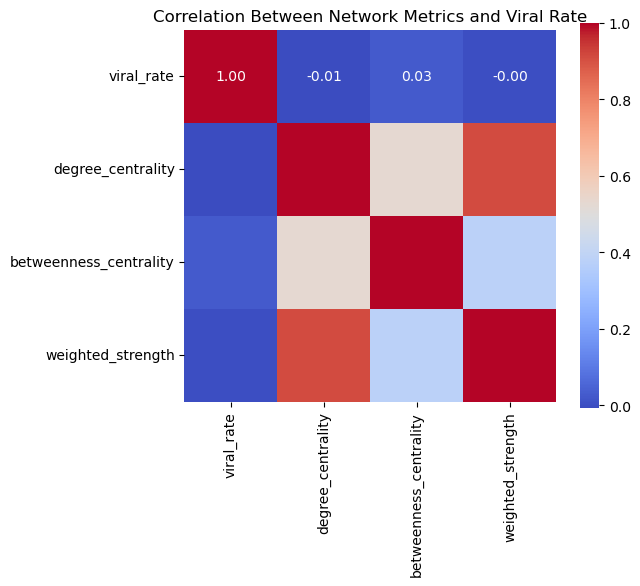

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

metric_cols = [
    "viral_rate",
    "degree_centrality",
    "betweenness_centrality",
    "weighted_strength"
]

corr_matrix = network_stats[metric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Between Network Metrics and Viral Rate")
plt.show()

### 4.6.4.4 Subreddit Activity (Post Count) as a Potential Confounding Factor

In [103]:
# Check whether subreddit activity (post_count) influences
# viral rate or network centrality
# This helps determine if larger subreddits bias the results

from scipy.stats import spearmanr

# Spearman correlation: subreddit size vs viral rate
rho_pc_v, p_pc_v = spearmanr(eval_df["post_count"], eval_df["viral_rate"])

# Spearman correlation: subreddit size vs degree centrality
rho_pc_d, p_pc_d = spearmanr(eval_df["post_count"], eval_df["degree_centrality"])

print(f"Spearman (post_count vs viral_rate): rho={rho_pc_v:.3f}, p={p_pc_v:.4f}")
print(f"Spearman (post_count vs degree_centrality): rho={rho_pc_d:.3f}, p={p_pc_d:.4f}")

Spearman (post_count vs viral_rate): rho=0.168, p=0.3759
Spearman (post_count vs degree_centrality): rho=0.046, p=0.8107
